# Классификация

In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

import numpy as np
np.random.seed(42)
import re
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, StackingClassifier
import lightgbm as lgb

import seaborn as sns
import matplotlib.pyplot as plt
color = "#FF0000"

BOLD = '\033[1m'
END = '\033[0m'

import warnings
warnings.filterwarnings('ignore')

## 1 Сбор и первичный анализ данных

### 1.1 Сбор данных

In [2]:
df_videos = pd.read_csv('videos.csv', encoding='latin-1')
df_videos

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/shantellmartin\nCANDICE - https://www.lovebilly.com\n\nfilmed this video in 4k on this -- http://amzn.to/2sTDnRZ\nwith this lens -- http://amzn.to/2rUJOmD\nbig drone - http://tinyurl.com/h4ft3oy\nOTHER GEAR --- http://amzn.to/2o3GLX5\nSony CAMERA http://amzn.to/2nOBmnv\nOLD CAMERA; http://amzn.to/2o2cQBT\nMAIN LENS; http://amzn.to/2od5gBJ\nBIG SONY CAMERA; http://amzn.to/2nrdJRO\nBIG Canon CAMERA; http://tinyurl.com/jn4q4vz\nBENDY TRIPOD THING; http://tinyurl.com/gw3ylz2\nYOU NEED THIS FOR THE BENDY TRIPOD; http://tinyurl.com/j8mzzua\nWIDE LENS; http://tinyurl.com/jkfcm8t\nMORE EXPENSIVE WIDE LENS; http://tinyurl.com/zrdgtou\nSMALL CAMERA; http://tinyurl.com/hrrzhor\nMICROPHONE; http://tinyurl.com/zefm4jy\nOTHER MICROPHONE; http://tinyurl.com/jxgpj86\nOLD DRONE (cheaper but still great);http://tinyurl.com/zcfmnmd\n\nfollow me; on http://instagram.com/caseyneistat\non https://www.facebook.com/cneistat\non https://twitter.com/CaseyNeistat\n\namazing intro song by https://soundcloud.com/discoteeth\n\nad disclosure. THIS IS NOT AN AD. not selling or promoting anything. but samsung did produce the Shantell Video as a 'GALAXY PROJECT' which is an initiative that enables creators like Shantell and me to make projects we might otherwise not have the opportunity to make. hope that's clear. if not ask in the comments and i'll answer any specifics.
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with John Oliver (HBO),LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week tonight donald trump""|""john oliver trump""|""donald trump""",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John Oliver discusses what we've learned so far and enlists our catheter cowboy to teach Donald Trump what he hasn't.\n\nConnect with Last Week Tonight online...\n\nSubscribe to the Last Week Tonight YouTube channel for more almost news as it almost happens: www.youtube.com/user/LastWeekTonight\n\nFind Last Week Tonight on Facebook like your mom would: http://Facebook.com/LastWeekTonight\n\nFollow us on Twitter for news about jokes and jokes about news: http://Twitter.com/LastWeekTonight\n\nVisit our official site for all that other stuff at once: http://www.hbo.com/lastweektonight"
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Lele Pons",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""|""racist""|""superman""|""love""|""rudy mancuso poo bear black white official music video""|""iphone x by pineapple""|""lelepons""|""hannahstocking""|""rudymancuso""|""inanna""|""anwar""|""sarkis""|""shots""|""shotsstudios""|""alesso""|""anitta""|""brazil""|""Getting My Driver's License | Lele Pons""",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº https://www.youtube.com/channel/UC5jkXpfnBhlDjqh0ir5FsIQ?sub_confirmation=1\n\nTHANKS FOR WATCHING! LIKE & SUBSCRIBE FOR MORE VIDEOS!\n-----------------------------------------------------------\nFIND ME ON: \nInstagram | http://instagram.com/rudymancuso\nTwitter | http://twitter.com/rudymancuso\nFacebook | http://facebook.com/rudymancuso\n\nCAST: \nRudy Mancuso | http://youtube.com/c/rudymancuso\nLele Pons | http://youtube.com/c/lelepons\nKing Bach | https://youtube.com/user/BachelorsPadTv\n\nVideo Effects: \nCaleb Natale | https://instagram.com/calebnatale\n\nPA:\nPaulina Gregory\n\n\nShots Studios Channels:\

In [3]:
print(f"\nРазмерность (количество наблюдений, количество признаков): {df_videos.shape}")
print(f"\nТипы данных:\n{df_videos.dtypes}")

missing = df_videos.isnull().sum()
missing_percent = (missing / len(df_videos)) * 100
missing_df = pd.DataFrame({'Количество пропусков': missing, 'Доля (%)': missing_percent})
missing_df = missing_df[missing_df['Количество пропусков'] > 0].sort_values('Доля (%)', ascending=False)

if not missing_df.empty:
    print(f"\nПропуски в данных:\n{missing_df}")
else:
    print("\nПропуски в данных отсутствуют.")


Размерность (количество наблюдений, количество признаков): (40949, 16)

Типы данных:
video_id                    str
trending_date               str
title                       str
channel_title               str
category_id               int64
publish_time                str
tags                        str
views                     int64
likes                     int64
dislikes                  int64
comment_count             int64
thumbnail_link              str
comments_disabled          bool
ratings_disabled           bool
video_error_or_removed     bool
description                 str
dtype: object

Пропуски в данных:
             Количество пропусков  Доля (%)
description                   570  1.391975


### 1.2 Визуализация данных

In [4]:
features_numeric = ['views', 'likes', 'dislikes', 'comment_count']
df_numeric = df_videos[features_numeric].fillna(0)

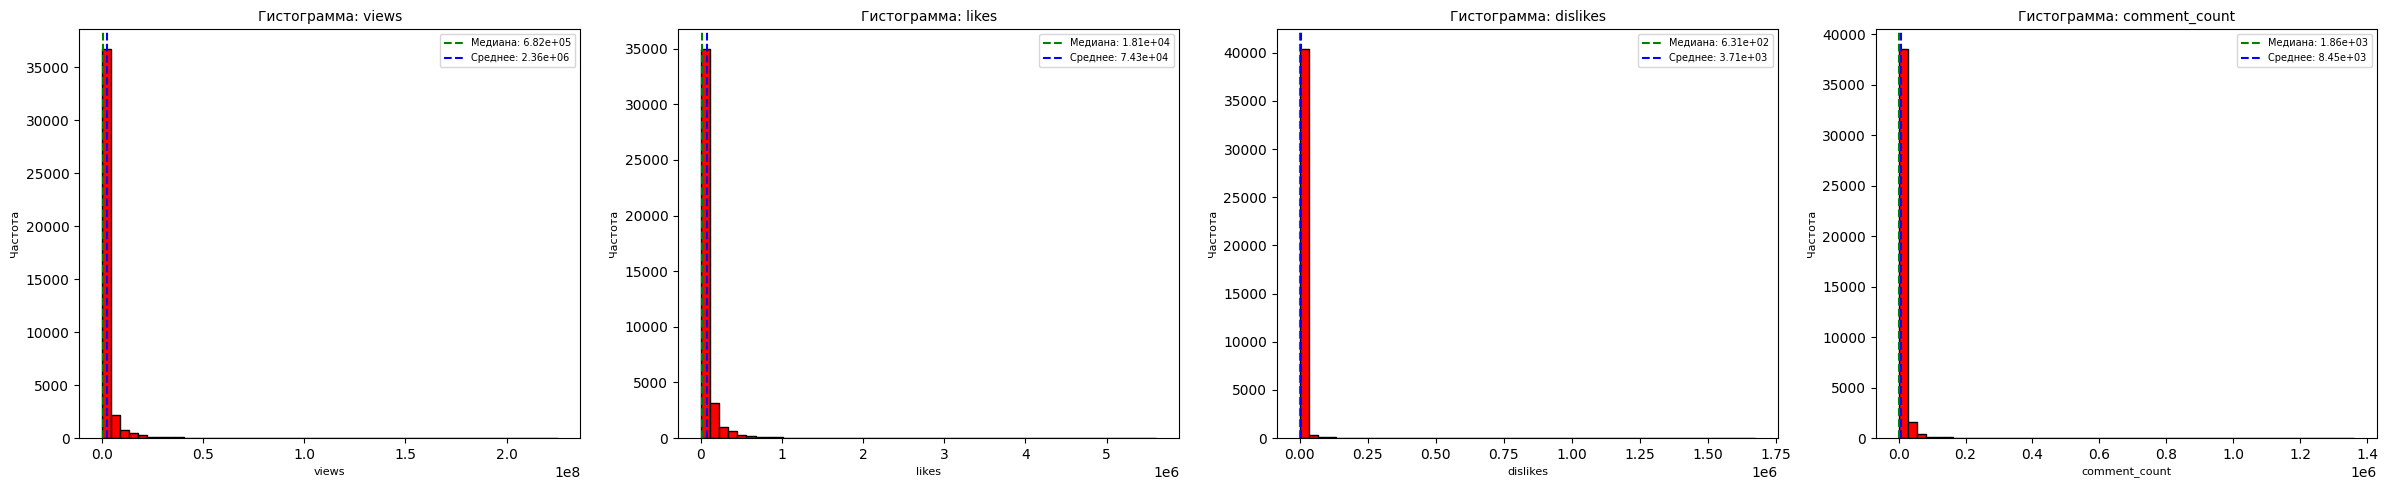

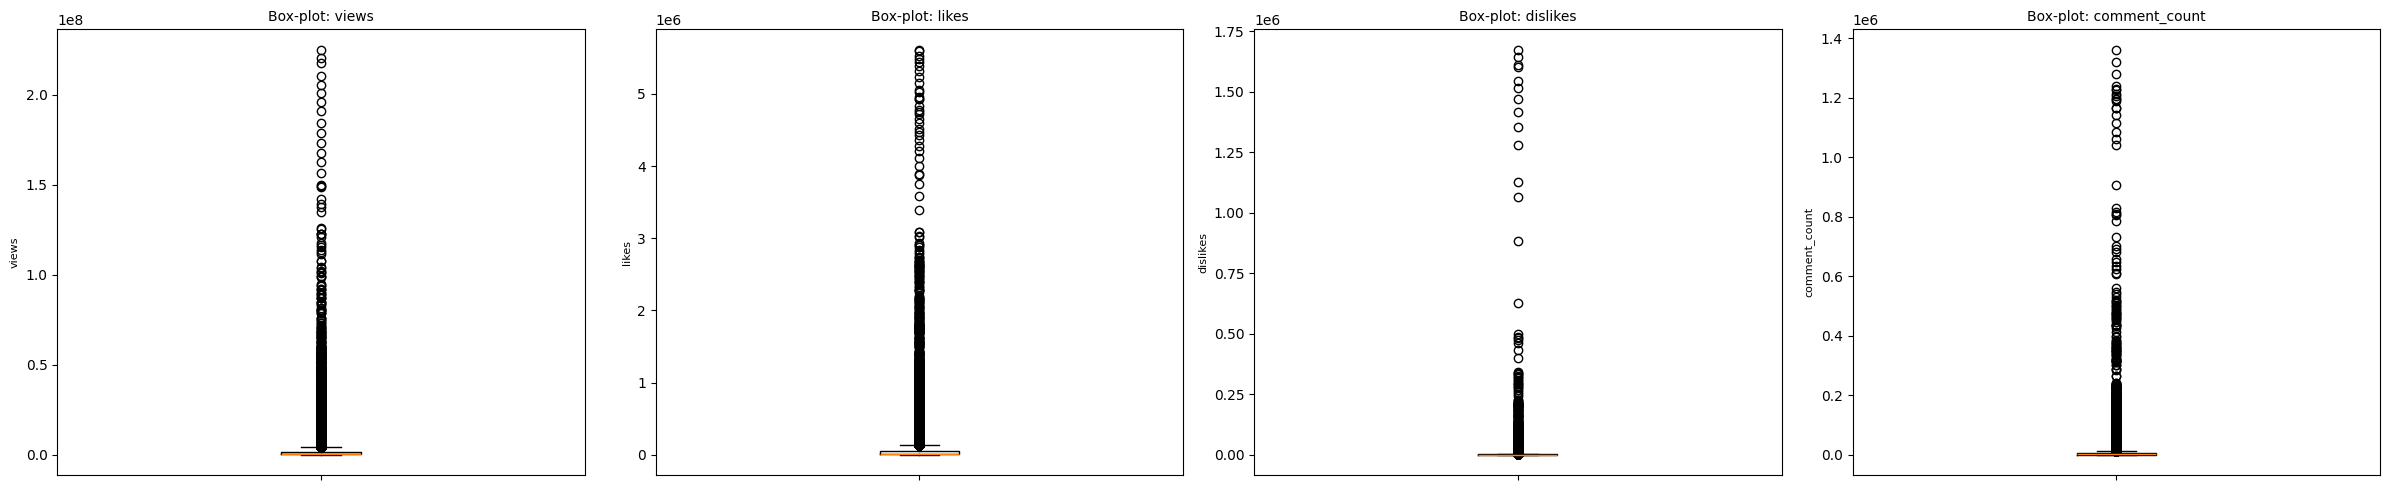

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
axes = axes.flatten()
for i, feature in enumerate(features_numeric):
    clean_data = df_numeric[feature].fillna(0)
    axes[i].hist(clean_data, bins=50, color=color, edgecolor='black')
    axes[i].set_title(f'Гистограмма: {feature}', fontsize=10)
    axes[i].set_xlabel(feature, fontsize=8)
    axes[i].set_ylabel('Частота', fontsize=8)
    axes[i].axvline(clean_data.median(), color='green', linestyle='--', 
                    label=f'Медиана: {clean_data.median():.2e}')
    axes[i].axvline(clean_data.mean(), color='blue', linestyle='--', 
                    label=f'Среднее: {clean_data.mean():.2e}')
    axes[i].legend(fontsize=7)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
axes = axes.flatten()
for i, feature in enumerate(features_numeric):
    clean_data = df_numeric[feature].fillna(0)
    axes[i].boxplot(clean_data)
    axes[i].set_title(f'Box-plot: {feature}', fontsize=10)
    axes[i].set_ylabel(feature, fontsize=8)
    axes[i].set_xticklabels([])

plt.tight_layout()
plt.show()

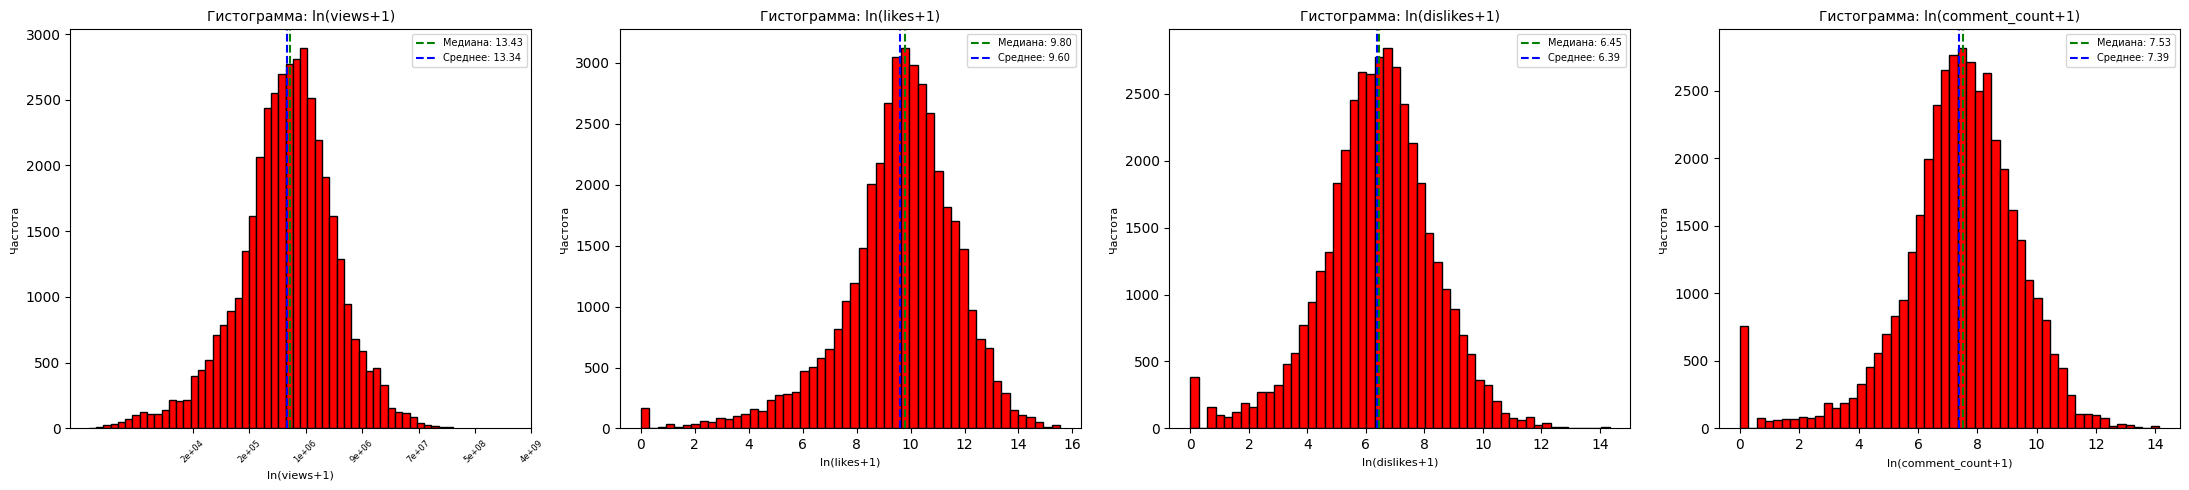

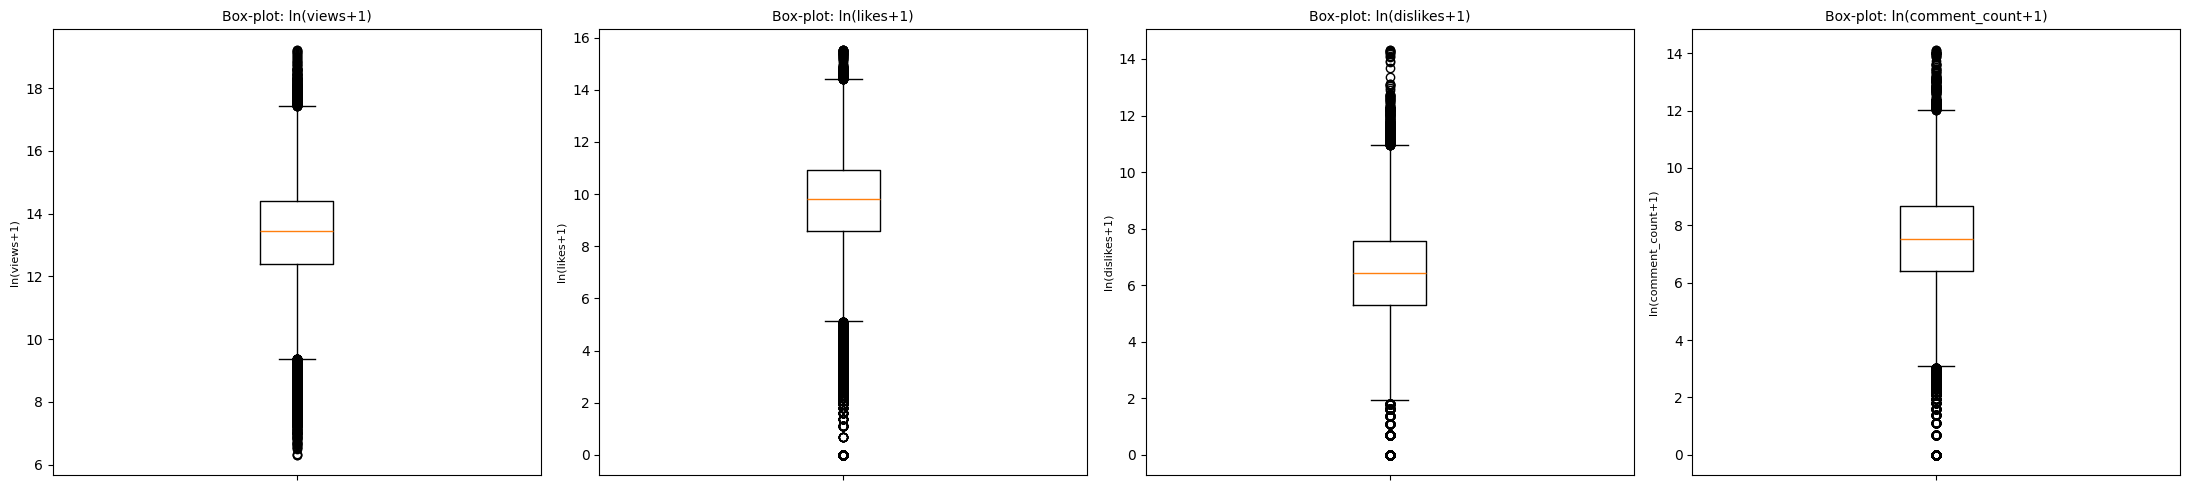

In [9]:
df_log = pd.DataFrame()
log_features = []

for feature in features_numeric:
    log_name = f"{feature}_log"
    df_log[log_name] = np.log1p(df_numeric[feature])
    log_features.append(log_name)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes = axes.flatten()
for i, feature in enumerate(log_features):
    clean_data = df_log[feature].dropna()
    original_name = feature.replace('_log', '')
    axes[i].hist(clean_data, bins=50, color=color, edgecolor='black')
    axes[i].set_title(f'Гистограмма: ln({original_name}+1)', fontsize=10)
    axes[i].set_xlabel(f'ln({original_name}+1)', fontsize=8)
    axes[i].set_ylabel('Частота', fontsize=8)
    
    axes[i].axvline(clean_data.median(), color='green', linestyle='--', 
                    label=f'Медиана: {clean_data.median():.2f}')
    axes[i].axvline(clean_data.mean(), color='blue', linestyle='--', 
                    label=f'Среднее: {clean_data.mean():.2f}')
    axes[i].legend(fontsize=7)
    # Добавляем метки исходных значений для интерпретации (для логарифмированных признаков)
    if 'subscribers' in feature or 'views' in feature:
        log_ticks = [10, 12, 14, 16, 18, 20, 22]
        axes[i].set_xticks(log_ticks)
        labels = [f'{np.exp(tick):.0e}' for tick in log_ticks]
        axes[i].set_xticklabels(labels, rotation=45, fontsize=6)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes = axes.flatten()
for i, feature in enumerate(log_features):
    clean_data = df_log[feature].dropna()
    original_name = feature.replace('_log', '')
    axes[i].boxplot(clean_data)
    if feature != 'age_days':
        axes[i].set_title(f'Box-plot: ln({original_name}+1)', fontsize=10)
        axes[i].set_ylabel(f'ln({original_name}+1)', fontsize=8)
    else:
        axes[i].set_title(f'Box-plot: {feature}', fontsize=10)
        axes[i].set_ylabel(feature, fontsize=8)
    axes[i].set_xticklabels([])
plt.tight_layout()
plt.show()

In [10]:
def stats(df, features):
    results = []
    
    for feature in features:
        data = df[feature].dropna()
        
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        outlier_count = len(outliers)
        outlier_percent = (outlier_count / len(data)) * 100
        
        results.append({
            'Признак': feature,
            'Математическое ожидание (среднее)': data.mean(),
            'Дисперсия': data.var(),
            'Минимум': data.min(),
            'Q1 (25% квартиль)': Q1,
            'Q2 (Медиана)': data.quantile(0.5),
            'Q3 (75% квартиль)': Q3,
            'Максимум': data.max(),
            'IQR': IQR,
            'Нижняя граница': round(lower_bound, 2),
            'Верхняя граница': round(upper_bound, 2),
            'Количество выбросов': outlier_count,
            'Доля выбросов (%)': round(outlier_percent, 2)
        })
    
    results_df = pd.DataFrame(results).set_index('Признак')
    return results_df

videos_stats = stats(df_numeric, features_numeric)
videos_stats.T

Признак,views,likes,dislikes,comment_count
Математическое ожидание (среднее),2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
Дисперсия,5.467292e+13,5.238850e+10,8.427238e+08,1.401041e+09
Минимум,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
Q1 (25% квартиль),2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
Q2 (Медиана),6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
Q3 (75% квартиль),1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
Максимум,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06
IQR,1.580828e+06,4.999300e+04,1.736000e+03,5.141000e+03
Нижняя граница,-2.128913e+06,-6.956550e+04,-2.402000e+03,-7.097500e+03
Верхняя граница,4.194399e+06,1.304065e+05,4.542000e+03,1.346650e+04


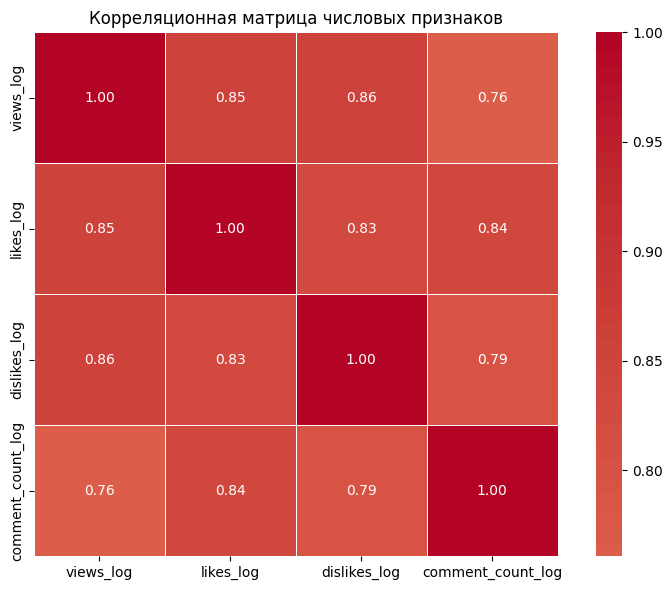

In [17]:
corr_matrix = df_log.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

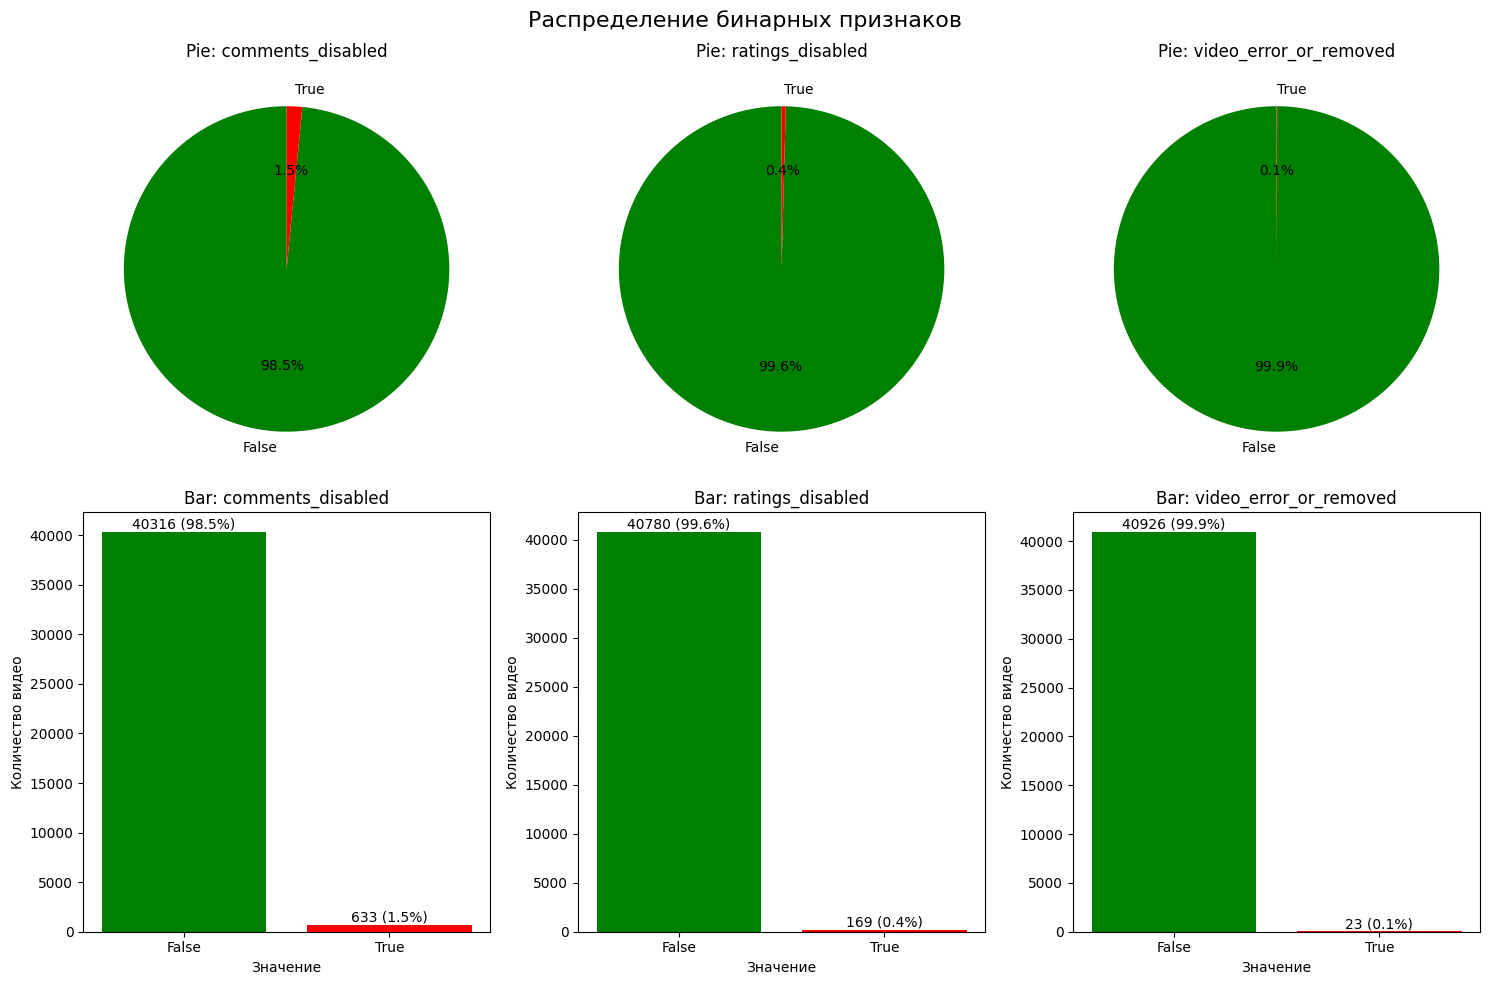

In [18]:
videos_binary_features = ['comments_disabled', 'ratings_disabled', 'video_error_or_removed']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, feature in enumerate(videos_binary_features):
    counts = df_videos[feature].value_counts()
    
    axes[0, i].pie(counts.values, labels=['False', 'True'], autopct='%1.1f%%', 
                   colors=['green', color], startangle=90)
    axes[0, i].set_title(f'Pie: {feature}')

for i, feature in enumerate(videos_binary_features):
    counts = df_videos[feature].value_counts()
    
    axes[1, i].bar(['False', 'True'], counts.values, color=['green', color])
    axes[1, i].set_title(f'Bar: {feature}')
    axes[1, i].set_xlabel('Значение')
    axes[1, i].set_ylabel('Количество видео')
    
    total = len(df_videos)
    for j, (idx, val) in enumerate(counts.items()):
        percent = (val / total) * 100
        axes[1, i].text(j, val + 50, f'{val} ({percent:.1f}%)', ha='center', va='bottom')

plt.suptitle('Распределение бинарных признаков', fontsize=16)
plt.tight_layout()
plt.show()

Всего уникальных каналов: 2207


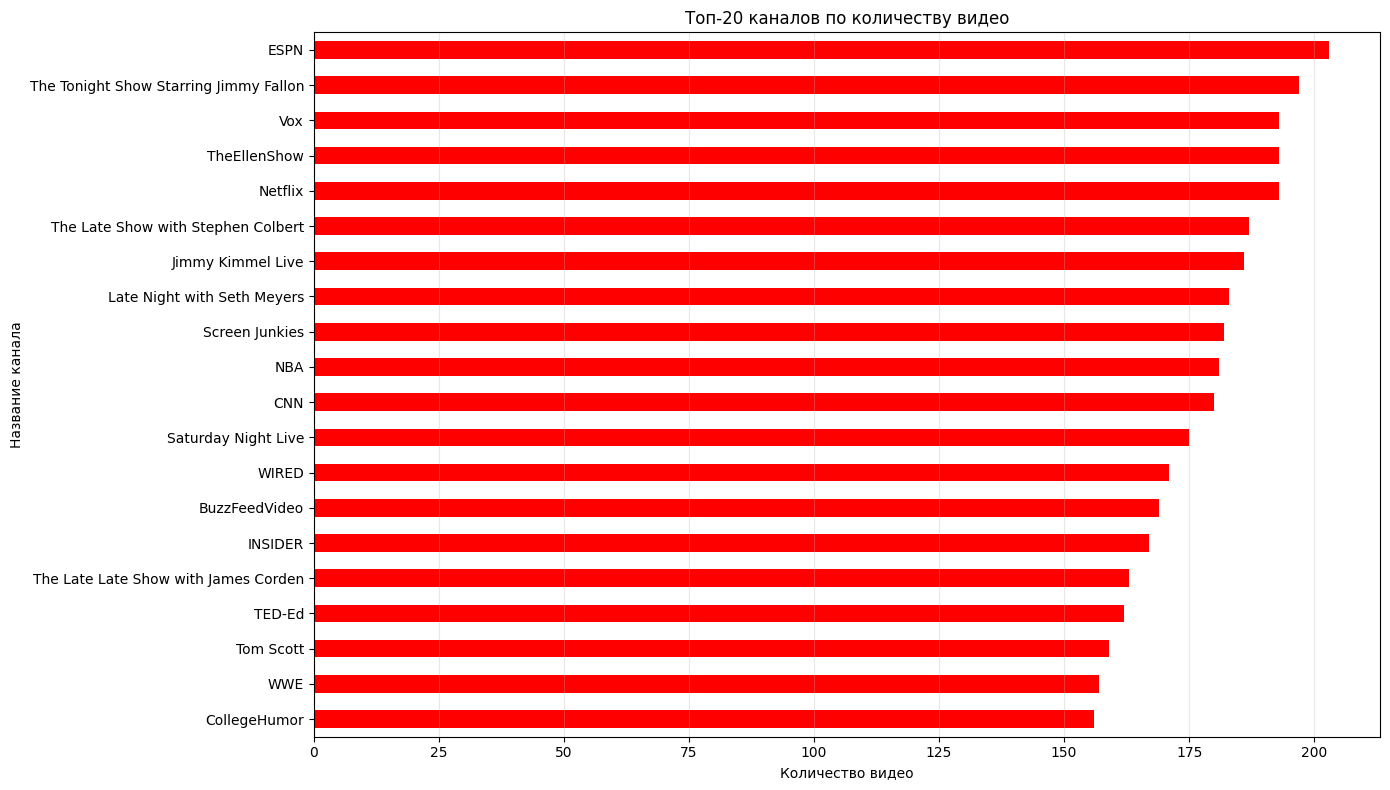

In [19]:
print(f"Всего уникальных каналов: {df_videos['channel_title'].nunique()}")

channel_counts = df_videos['channel_title'].value_counts().head(20)

plt.figure(figsize=(14, 8))
channel_counts[::-1].plot(kind='barh', color=color)
plt.title('Топ-20 каналов по количеству видео')
plt.xlabel('Количество видео')
plt.ylabel('Название канала')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

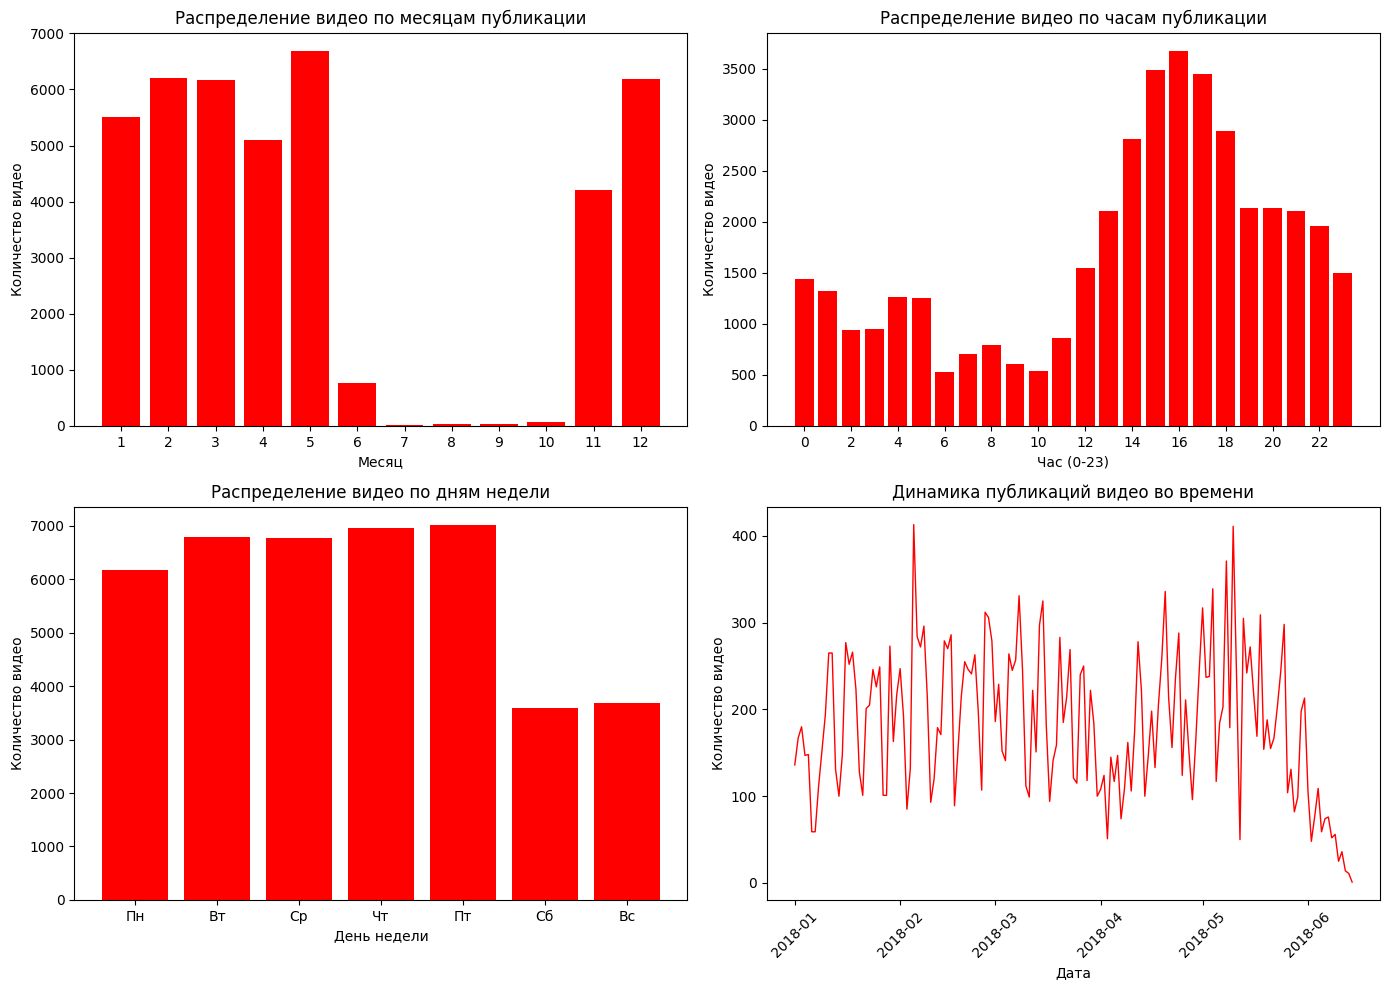

Статистика по времени публикации:
Самый популярный месяц: 5 (6681 видео)
Самый популярный час: 16:00 (3669 видео)
Самый популярный день: Пт (7002 видео)


In [20]:
# Преобразование временных признаков
df_videos['trending_date'] = pd.to_datetime(df_videos['trending_date'], format='%y.%d.%m')
df_videos['publish_time'] = pd.to_datetime(df_videos['publish_time'])

# Извлечение признаков из даты публикации
df_videos['publish_year'] = df_videos['publish_time'].dt.year
df_videos['publish_month'] = df_videos['publish_time'].dt.month
df_videos['publish_day'] = df_videos['publish_time'].dt.day
df_videos['publish_hour'] = df_videos['publish_time'].dt.hour
df_videos['publish_dayofweek'] = df_videos['publish_time'].dt.dayofweek

# Анализ дня недели публикации
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Распределение по месяцам
month_counts = df_videos['publish_month'].value_counts().sort_index()
axes[0, 0].bar(month_counts.index, month_counts.values, color=color)
axes[0, 0].set_title('Распределение видео по месяцам публикации')
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('Количество видео')
axes[0, 0].set_xticks(range(1, 13))

# Распределение по часам
hour_counts = df_videos['publish_hour'].value_counts().sort_index()
axes[0, 1].bar(hour_counts.index, hour_counts.values, color=color)
axes[0, 1].set_title('Распределение видео по часам публикации')
axes[0, 1].set_xlabel('Час (0-23)')
axes[0, 1].set_ylabel('Количество видео')
axes[0, 1].set_xticks(range(0, 24, 2))

# Распределение по дням недели
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
dow_counts = df_videos['publish_dayofweek'].value_counts().sort_index()
axes[1, 0].bar(days, dow_counts.values, color=color)
axes[1, 0].set_title('Распределение видео по дням недели')
axes[1, 0].set_xlabel('День недели')
axes[1, 0].set_ylabel('Количество видео')

# Временной ряд количества видео по датам
daily_counts = df_videos['publish_time'].dt.date.value_counts().sort_index()
daily_counts = daily_counts[daily_counts.index >= pd.to_datetime('2018-01-01').date()]  # ограничим для наглядности
axes[1, 1].plot(daily_counts.index, daily_counts.values, linewidth=1, color=color)
axes[1, 1].set_title('Динамика публикаций видео во времени')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Количество видео')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Статистика по времени публикации:")
print(f"Самый популярный месяц: {month_counts.idxmax()} ({month_counts.max()} видео)")
print(f"Самый популярный час: {hour_counts.idxmax()}:00 ({hour_counts.max()} видео)")
print(f"Самый популярный день: {days[dow_counts.argmax()]} ({dow_counts.max()} видео)")

### 1.3. Предобработка данных

In [44]:
classification_features = [
    'views', 'likes', 'dislikes', 'comment_count',
    'comments_disabled', 'ratings_disabled', 'video_error_or_removed',
    'trending_date', 'publish_time', 'channel_title', 'tags',
    'category_id'
]

df = df_videos[classification_features].copy()

df

,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,trending_date,publish_time,channel_title,tags,category_id
0,748374,57527,2966,15954,False,False,False,2017-11-14,2017-11-13 17:13:01+00:00,CaseyNeistat,SHANtell martin,22
1,2418783,97185,6146,12703,False,False,False,2017-11-14,2017-11-13 07:30:00+00:00,LastWeekTonight,"last week tonight trump presidency|""last week tonight donald trump""|""john oliver trump""|""donald trump""",24
2,3191434,146033,5339,8181,False,False,False,2017-11-14,2017-11-12 19:05:24+00:00,Rudy Mancuso,"racist superman|""rudy""|""mancuso""|""king""|""bach""|""racist""|""superman""|""love""|""rudy mancuso poo bear black white official music video""|""iphone x by pineapple""|""lelepons""|""hannahstocking""|""rudymancuso""|""inanna""|""anwar""|""sarkis""|""shots""|""shotsstudios""|""alesso""|""anitta""|""brazil""|""Getting My Driver's License | Lele Pons""",23
3,343168,10172,666,2146,False,False,False,2017-11-14,2017-11-13 11:00:04+00:00,Good Mythical Morning,"rhett and link|""gmm""|""good mythical morning""|""rhett and link good mythical morning""|""good mythical morning rhett and link""|""mythical morning""|""Season 12""|""nickelback lyrics""|""nickelback lyrics real or fake""|""nickelback""|""nickelback songs""|""nickelback song""|""rhett link nickelback""|""gmm nickelback""|""lyrics (website category)""|""nickelback (musical group)""|""rock""|""music""|""lyrics""|""chad kroeger""|""canada""|""music (industry)""|""mythical""|""gmm challenge""|""comedy""|""funny""|""challenge""",24
4,2095731,132235,1989,17518,False,False,False,2017-11-14,2017-11-12 18:01:41+00:00,nigahiga,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""idy""|""rhpc""|""dares""|""no truth""|""comments""|""comedy""|""funny""|""stupid""|""fail""",24
...,...,...,...,...,...,...,...,...,...,...,...,...
40944,1685609,38160,1385,2657,False,False,False,2018-06-14,2018-05-18 13:00:04+00:00,AaronsAnimals,"aarons animals|""aarons""|""animals""|""cat""|""cats""|""kitten""|""kittens""|""prince michael""|""prince""|""michael""|""laser""|""olympics""|""red""|""dream""",15
40945,1064798,60008,382,3936,False,False,False,2018-06-14,2018-05-18 01:00:06+00:00,zefrank1,[none],22
40946,1066451,48068,1032,3992,False,False,False,2018-06-14,2018-05-18 17:34:22+00:00,Brad Mondo,"I gave safiya nygaard a perfect hair makeover based on her features: bts|""brad mondo""|""safiya and tyler""|""safiya nygaard""|""hair transformation""|""makeover""|""I got a perfect makeover based on my features""|""bts""|""hairdresser reacts""|""before and after""|""hair""|""makeup""|""transformation""|""ANTM""|""what not to wear""|""the ideal haircut and color for your face""|""safiya buzzfeed""|""color for your skin tone""|""haircut for your face shape""|""tutorial""|""balayage""|""hair stylist""|""hair color""|""hair tutorial""",24
40947,5660813,192957,2846,13088,False,False,False,2018-06-14,2018-05-17 17:00:04+00:00,How It Should Have Ended,"Black Panther|""HISHE""|""Marvel""|""Infinity War""|""How It Should Have Ended""|""parody""|""comedy""|""entertainment""|""wakanda""|""Chadwick Boseman""|""Michael B Jordan""|""movies""|""animation""|""fortnite""|""azerrz""|""movie""|""plothole""|""review""|""childish gambino""|""donald glover""|""this is america""|""ending explained""",1


In [45]:
df.isnull().sum()

views                     0
likes                     0
dislikes                  0
comment_count             0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
trending_date             0
publish_time              0
channel_title             0
tags                      0
category_id               0
dtype: int64

In [46]:
binary_cols = ['comments_disabled', 'ratings_disabled', 'video_error_or_removed']
for col in binary_cols:
    df[col] = df[col].astype(int)
    print(f"{col}: преобразован в int (0/1)")

channel_counts = df['channel_title'].value_counts()
df['channel_popularity'] = df['channel_title'].map(channel_counts) / len(df)
df['channel_popularity'] = df['channel_popularity'].fillna(0)
df = df.drop('channel_title', axis=1)
print("channel_title: создан признак популярности канала (channel_popularity)")

comments_disabled: преобразован в int (0/1)
ratings_disabled: преобразован в int (0/1)
video_error_or_removed: преобразован в int (0/1)
channel_title: создан признак популярности канала (channel_popularity)


In [47]:
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m', errors='coerce')
df['trending_year'] = df['trending_date'].dt.year
df['trending_month'] = df['trending_date'].dt.month
df['trending_day'] = df['trending_date'].dt.day
df['trending_dayofweek'] = df['trending_date'].dt.dayofweek
print("trending_date: извлечены год, месяц, день, день недели")

df['publish_time'] = pd.to_datetime(df['publish_time'])
df['publish_year'] = df['publish_time'].dt.year
df['publish_month'] = df['publish_time'].dt.month
df['publish_day'] = df['publish_time'].dt.day
df['publish_hour'] = df['publish_time'].dt.hour
df['publish_dayofweek'] = df['publish_time'].dt.dayofweek
print("publish_time: извлечены год, месяц, день, день недели")

df = df.drop(['trending_date', 'publish_time'], axis=1)

trending_date: извлечены год, месяц, день, день недели
publish_time: извлечены год, месяц, день, день недели


### 1.4. Нормализация и стандартизация данных

In [48]:
print(f"\n{BOLD}Логарифмическое преобразование{END} применено к признакам:")
for feature in features_numeric:
    df[feature + '_log'] = np.log1p(df[feature])
    df = df.drop(feature, axis=1)
    print(f"\t{feature} → {feature}_log")

print(f"\n{BOLD}Стандартизация (Z-масштабирование){END} применена к признакам:")
scale_features = [feature + '_log' for feature in features_numeric]
scaler = StandardScaler()
df[scale_features] = scaler.fit_transform(df[scale_features])
print('\t' + '\n\t'.join(scale_features))


Логарифмическое преобразование применено к признакам:
	views → views_log
	likes → likes_log
	dislikes → dislikes_log
	comment_count → comment_count_log

Стандартизация (Z-масштабирование) применена к признакам:
	views_log
	likes_log
	dislikes_log
	comment_count_log


### 1.5 Разделение данных на обучающую и тестовую выборки

In [49]:
X = df.drop('category_id', axis=1)
y = df['category_id']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Количество классов: {len(np.unique(y))}")

Размер обучающей выборки: (28664, 18)
Размер тестовой выборки: (12285, 18)
Количество классов: 16


In [50]:
vectorizer = CountVectorizer(
    tokenizer=lambda x: x.split('|'),
    lowercase=False,
    max_features=1000
)

tags_train = vectorizer.fit_transform(X_train['tags'])
tags_train_df = pd.DataFrame(
    tags_train.toarray(),
    columns=[f'tag_{col}' for col in vectorizer.get_feature_names_out()],
    index=X_train.index
)

tags_test = vectorizer.transform(X_test['tags'])
tags_test_df = pd.DataFrame(
    tags_test.toarray(),
    columns=[f'tag_{col}' for col in vectorizer.get_feature_names_out()],
    index=X_test.index
)

X_train_final = pd.concat([X_train.drop('tags', axis=1), tags_train_df], axis=1)
X_test_final = pd.concat([X_test.drop('tags', axis=1), tags_test_df], axis=1)

print(f"Итоговое количество признаков: {X_train_final.shape[1]}")
print(f"Из них признаков тегов: {len(tags_train_df.columns)}")
# print(*tags_train_df.columns.tolist(), sep='\n')

Итоговое количество признаков: 1017
Из них признаков тегов: 1000


## 2 Решение задачи классификации

In [133]:
def scores(y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    return accuracy, precision, recall, f1

def report(y_pred):
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title('Матрица ошибок')
    plt.ylabel('Истинные значения')
    plt.xlabel('Предсказанные значения')
    plt.show()

### 2.1. Наивный байесовский классификатор


Classification Report:
              precision    recall  f1-score   support

           1       0.76      0.56      0.64       704
           2       0.38      0.07      0.12       115
          10       0.70      0.81      0.75      1942
          15       0.82      0.56      0.66       276
          17       0.95      0.58      0.72       652
          19       0.94      0.13      0.23       121
          20       0.82      0.27      0.41       245
          22       0.70      0.32      0.44       963
          23       0.93      0.59      0.72      1037
          24       0.48      0.78      0.60      2989
          25       0.61      0.62      0.62       746
          26       0.75      0.73      0.74      1244
          27       0.82      0.63      0.71       497
          28       0.68      0.44      0.53       720
          29       0.02      0.06      0.03        17
          43       1.00      0.76      0.87        17

    accuracy                           0.64     12285
  

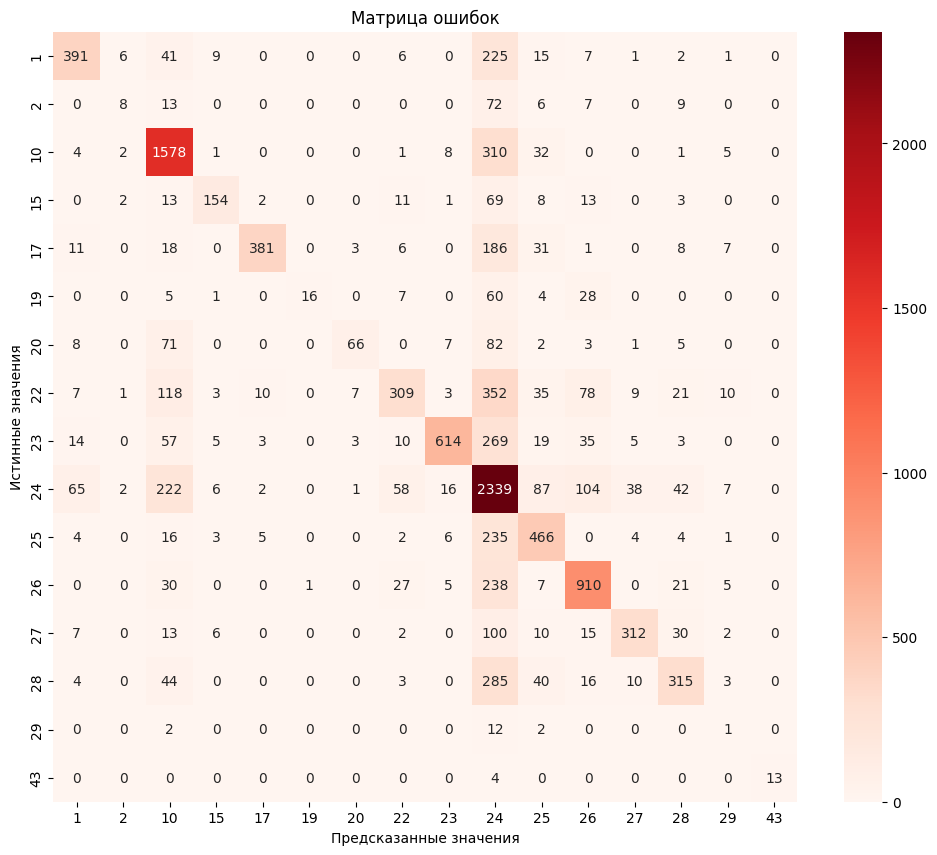

In [ ]:
continuous_features = ['views_log', 'likes_log', 'dislikes_log', 'comment_count_log',
                       'trending_year', 'trending_month', 'trending_day', 'trending_dayofweek',
                       'publish_year', 'publish_month', 'publish_day', 'publish_hour', 'publish_dayofweek',
                       'channel_popularity']

binary_features = ['comments_disabled', 'ratings_disabled', 'video_error_or_removed']

count_features = [f'tag_{col}' for col in vectorizer.get_feature_names_out()]

X_train_cont = X_train_final[continuous_features]
X_train_bin = X_train_final[binary_features]
X_train_cnt = X_train_final[count_features]
X_train_cnt = X_train_cnt.clip(lower=0)

X_test_cont = X_test_final[continuous_features]
X_test_bin = X_test_final[binary_features]
X_test_cnt = X_test_final[count_features]
X_test_cnt = X_test_cnt.clip(lower=0)

gnb = GaussianNB()
gnb.fit(X_train_cont, y_train)

bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train)

mnb = MultinomialNB()
mnb.fit(X_train_cnt, y_train)

def combined_nb_predict(X_cont, X_bin, X_cnt):
    # Получаем логарифмы вероятностей от каждой модели
    # Используем predict_log_proba для численной стабильности
    log_proba_cont = gnb.predict_log_proba(X_cont)
    log_proba_bin = bnb.predict_log_proba(X_bin)
    log_proba_cnt = mnb.predict_log_proba(X_cnt)
    
    # Комбинируем (суммируем логарифмы - это соответствует умножению вероятностей)
    combined_log_proba = log_proba_cont + log_proba_bin + log_proba_cnt
    
    # Возвращаем класс с максимальной суммой логарифмов
    return gnb.classes_[np.argmax(combined_log_proba, axis=1)]

y_pred_nb = combined_nb_predict(X_test_cont, X_test_bin, X_test_cnt)

nb_accuracy, nb_precision, nb_recall, nb_f1 = scores(y_pred_nb)
report(y_pred_nb)

### 2.2. Классификация на основе логистической регрессии


Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       704
           2       0.00      0.00      0.00       115
          10       0.35      0.49      0.41      1942
          15       0.00      0.00      0.00       276
          17       0.00      0.00      0.00       652
          19       0.00      0.00      0.00       121
          20       0.00      0.00      0.00       245
          22       0.00      0.00      0.00       963
          23       1.00      0.00      0.01      1037
          24       0.27      0.81      0.40      2989
          25       0.24      0.11      0.15       746
          26       0.77      0.02      0.05      1244
          27       0.00      0.00      0.00       497
          28       0.00      0.00      0.00       720
          29       0.00      0.00      0.00        17
          43       0.00      0.00      0.00        17

    accuracy                           0.29     12285
  

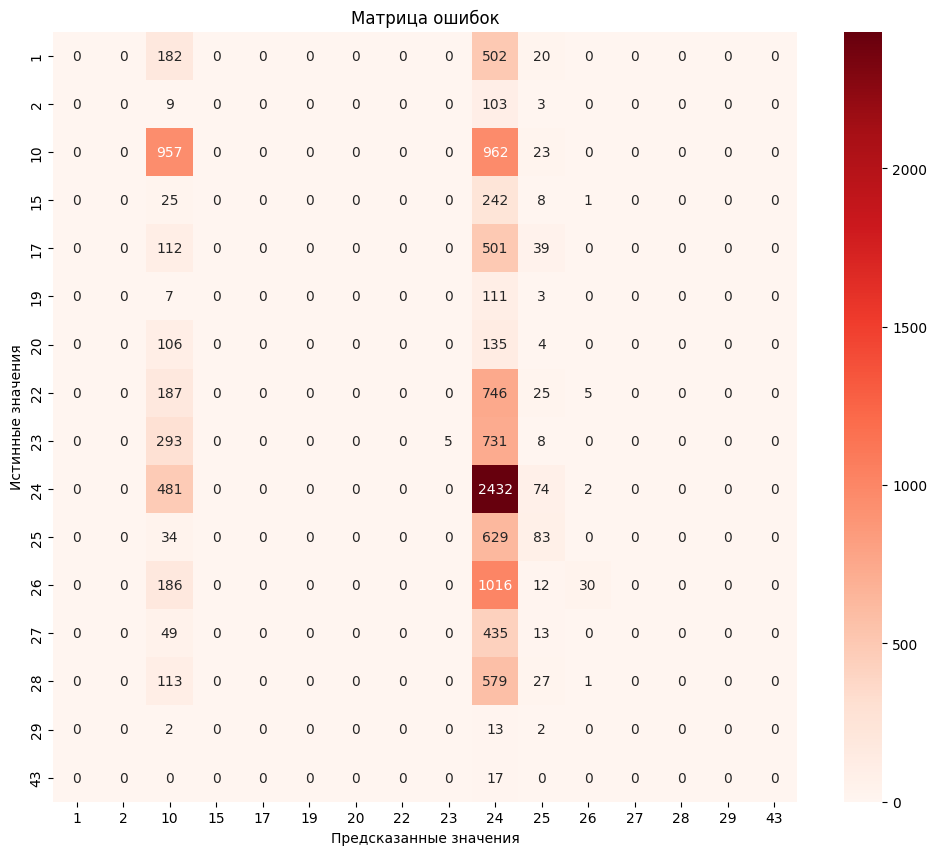

In [143]:
logreg = LogisticRegression(
    # multi_class='multinomial', 
    solver='lbfgs',
    max_iter=1000, random_state=42,
    verbose=2)
logreg.fit(X_train_final, y_train)

y_pred_logreg = logreg.predict(X_test_final)

logreg_accuracy, logreg_precision, logreg_recall, logreg_f1 = scores(y_pred_logreg)
report(y_pred_logreg)

In [ ]:
feature_names = X_train_final.columns
coefficients = logreg.coef_

class_index = list(logreg.classes_).index(24)

print("Признаки с наибольшим положительным влиянием на вероятность класса 24 (Entertainment):")
coef_class = coefficients[class_index]
top_positive_indices = np.argsort(coef_class)[-10:][::-1]  # 10 наибольших
for idx in top_positive_indices:
    if coef_class[idx] > 0:
        print(f"  {feature_names[idx]}: {coef_class[idx]:.4f}")

print("\nПризнаки с наибольшим отрицательным влиянием на вероятность класса 24 (Entertainment):")
top_negative_indices = np.argsort(coef_class)[:10]  # 10 наименьших
for idx in top_negative_indices:
    if coef_class[idx] < 0:
        print(f"  {feature_names[idx]}: {coef_class[idx]:.4f}")


Признаки с наибольшим положительным влиянием на вероятность класса 24 (Entertainment):
  views_log: 0.1035
  tag_"funny": 0.0884
  tag_"celebrity": 0.0842
  tag_"comedy": 0.0708
  tag_"comedian": 0.0678
  dislikes_log: 0.0674
  tag_"hollywood": 0.0664
  tag_"entertainment": 0.0556
  tag_"television": 0.0552
  tag_"late night": 0.0539

Признаки с наибольшим отрицательным влиянием на вероятность класса 24 (Entertainment):
  comment_count_log: -0.0681
  likes_log: -0.0563
  tag_"Pop": -0.0546
  tag_[none]: -0.0335
  tag_"science": -0.0307
  tag_"sports": -0.0250
  tag_"Records": -0.0249
  publish_dayofweek: -0.0238
  tag_"food": -0.0219
  tag_"technology": -0.0215


### 2.3. Метод ближайших соседей

k = 1	 accuracy = 0.8181522181522182
k = 2	 accuracy = 0.6751322751322751
k = 3	 accuracy = 0.6301994301994301
k = 4	 accuracy = 0.5702075702075702
k = 5	 accuracy = 0.5325193325193325
k = 6	 accuracy = 0.5010989010989011
k = 7	 accuracy = 0.48701668701668704
k = 8	 accuracy = 0.4722018722018722
k = 9	 accuracy = 0.46145706145706145
k = 10	 accuracy = 0.4502238502238502
k = 11	 accuracy = 0.44395604395604393
k = 12	 accuracy = 0.43475783475783475
k = 13	 accuracy = 0.4281644281644282
k = 14	 accuracy = 0.42165242165242167
k = 15	 accuracy = 0.4135124135124135
k = 16	 accuracy = 0.40927960927960927
k = 17	 accuracy = 0.4047212047212047
k = 18	 accuracy = 0.39747659747659747
k = 19	 accuracy = 0.3955229955229955
k = 20	 accuracy = 0.3908831908831909


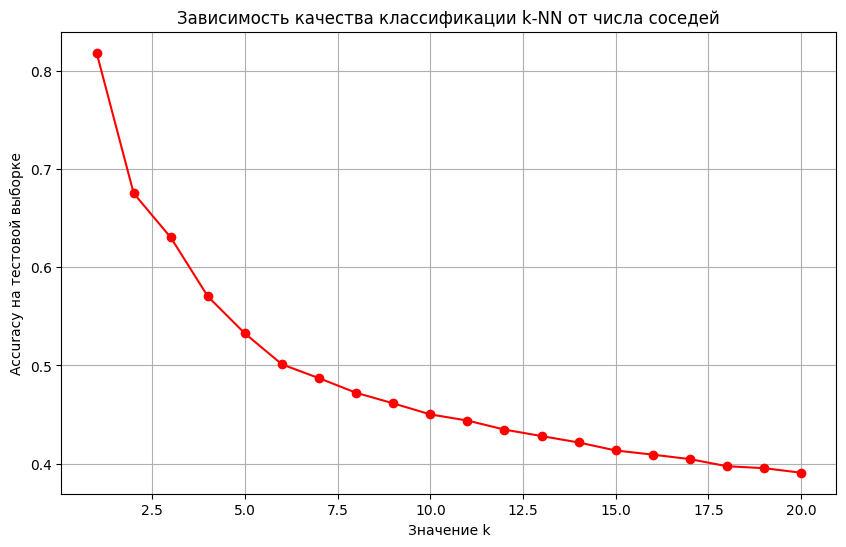

Оптимальное значение k: 1


In [ ]:
k_range = range(1, 21)
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_final, y_train)
    y_pred_knn = knn.predict(X_test_final)
    score = accuracy_score(y_test, y_pred_knn)
    k_scores.append(score)
    print(f"k = {k}\t accuracy = {score}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores, color=color, marker='o')
plt.xlabel('Значение k')
plt.ylabel('Accuracy на тестовой выборке')
plt.title('Зависимость качества классификации k-NN от числа соседей')
plt.grid(True)
plt.show()

best_k = k_range[np.argmax(k_scores)]
print(f"Оптимальное значение k: {best_k}")


Classification Report:
              precision    recall  f1-score   support

           1       0.83      0.81      0.82       704
           2       0.59      0.80      0.68       115
          10       0.78      0.85      0.82      1942
          15       0.83      0.78      0.80       276
          17       0.87      0.80      0.83       652
          19       0.74      0.72      0.73       121
          20       0.73      0.79      0.76       245
          22       0.79      0.78      0.78       963
          23       0.88      0.86      0.87      1037
          24       0.85      0.85      0.85      2989
          25       0.79      0.76      0.77       746
          26       0.86      0.82      0.84      1244
          27       0.82      0.79      0.81       497
          28       0.73      0.76      0.74       720
          29       0.81      0.76      0.79        17
          43       0.93      0.82      0.88        17

    accuracy                           0.82     12285
  

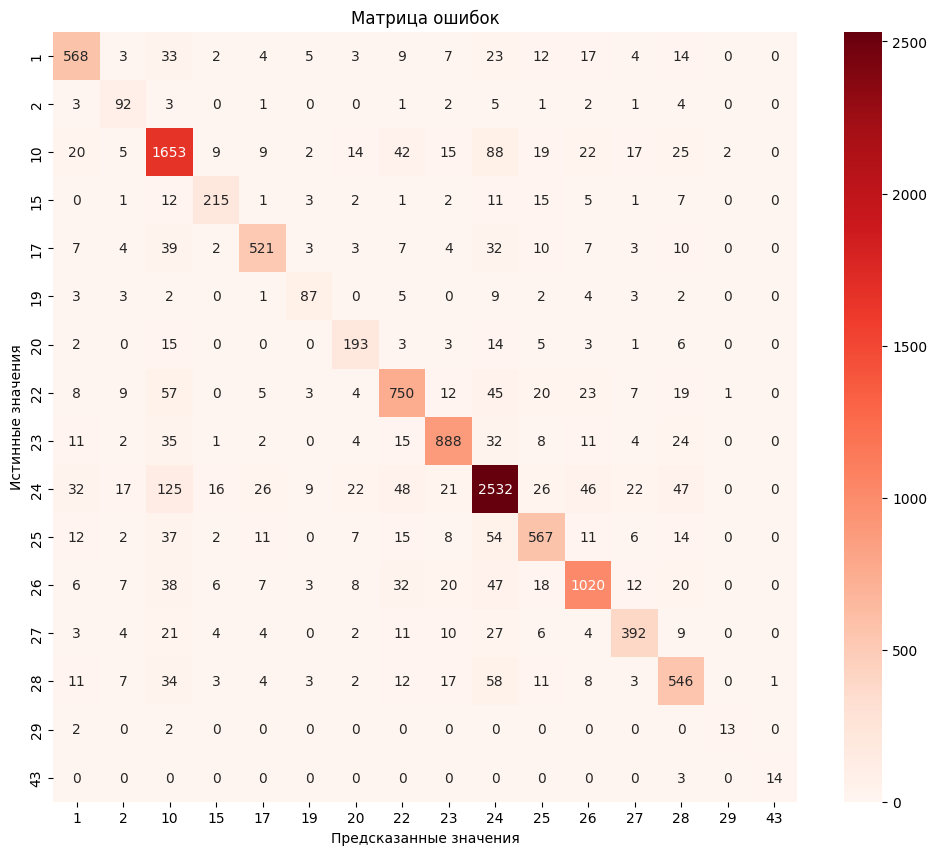

In [ ]:
knn_optimal = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_optimal.fit(X_train_final, y_train)
y_pred_knn = knn_optimal.predict(X_test_final)

knn_accuracy, knn_precision, knn_recall, knn_f1 = scores(y_pred_knn)
report(y_pred_knn)

### 2.4. Метод опорных векторов

In [136]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

linearsvc = LinearSVC(max_iter=3000, random_state=42, dual='auto')

grid_linearsvc = GridSearchCV(linearsvc, param_grid,
                              cv=3, scoring='accuracy', n_jobs=-1)
grid_linearsvc.fit(X_train_final, y_train)

print(f"Лучшие параметры LinearSVC: {grid_linearsvc.best_params_}")

Лучшие параметры LinearSVC: {'C': 100}



Classification Report:
              precision    recall  f1-score   support

           1       0.81      0.62      0.70       704
           2       0.67      0.21      0.32       115
          10       0.68      0.85      0.76      1942
          15       0.82      0.75      0.79       276
          17       0.92      0.69      0.79       652
          19       0.90      0.52      0.66       121
          20       0.97      0.32      0.48       245
          22       0.60      0.51      0.55       963
          23       0.88      0.78      0.83      1037
          24       0.61      0.80      0.69      2989
          25       0.75      0.78      0.76       746
          26       0.85      0.76      0.80      1244
          27       0.94      0.70      0.80       497
          28       0.77      0.45      0.57       720
          29       0.00      0.00      0.00        17
          43       1.00      1.00      1.00        17

    accuracy                           0.72     12285
  

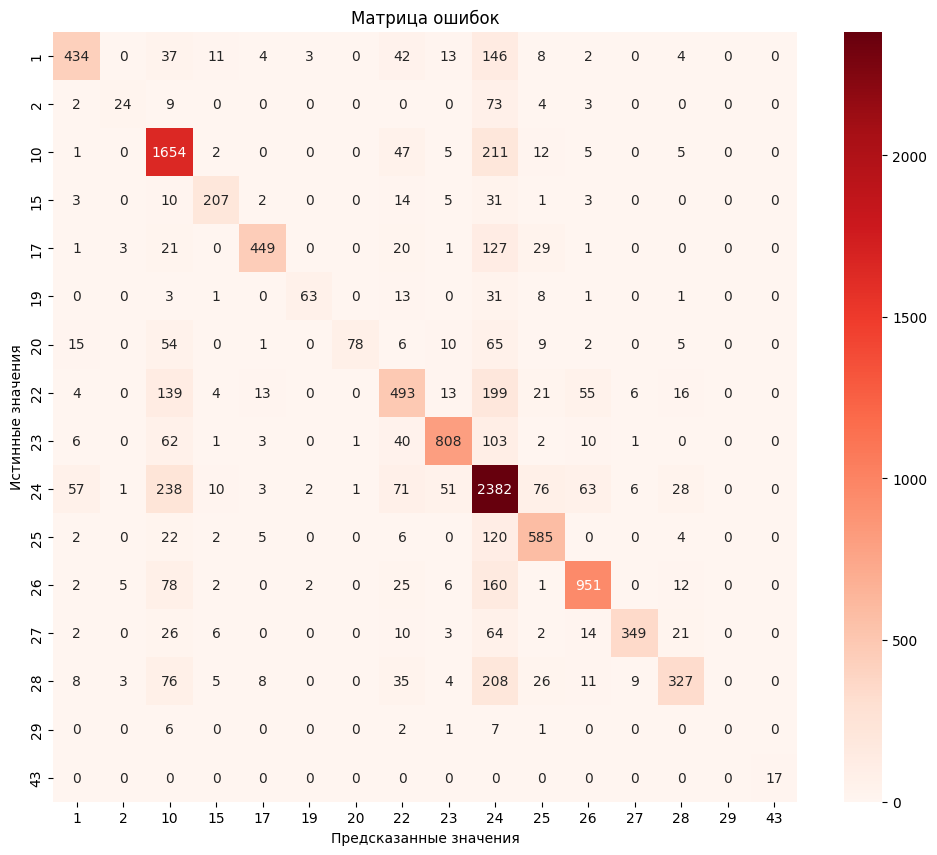

In [ ]:
linearsvc_optimal = grid_linearsvc.best_estimator_
y_pred_linearsvc = linearsvc_optimal.predict(X_test_final)

linearsvc_accuracy, linearsvc_precision, linearsvc_recall, linearsvc_f1 = scores(y_pred_linearsvc)
report(y_pred_linearsvc)

### 2.5. Деревья решений

In [ ]:
# Дерево без ограничений (полное дерево)
dt_full = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)
dt_full.fit(X_train_final, y_train)

# Оценка на обучающей и тестовой выборках
y_train_pred_full = dt_full.predict(X_train_final)
y_test_pred_full = dt_full.predict(X_test_final)

train_acc_full = accuracy_score(y_train, y_train_pred_full)
test_acc_full = accuracy_score(y_test, y_test_pred_full)

print("--- Дерево решений (без ограничений) ---")
print(f"Точность на ОБУЧАЮЩЕЙ выборке: {train_acc_full:.4f}")
print(f"Точность на ТЕСТОВОЙ выборке: {test_acc_full:.4f}")
print(f"Глубина дерева: {dt_full.get_depth()}")
print(f"Количество листьев: {dt_full.get_n_leaves()}")

--- Дерево решений (без ограничений) ---
Точность на ОБУЧАЮЩЕЙ выборке: 1.0000
Точность на ТЕСТОВОЙ выборке: 0.9284
Глубина дерева: 76
Количество листьев: 2923


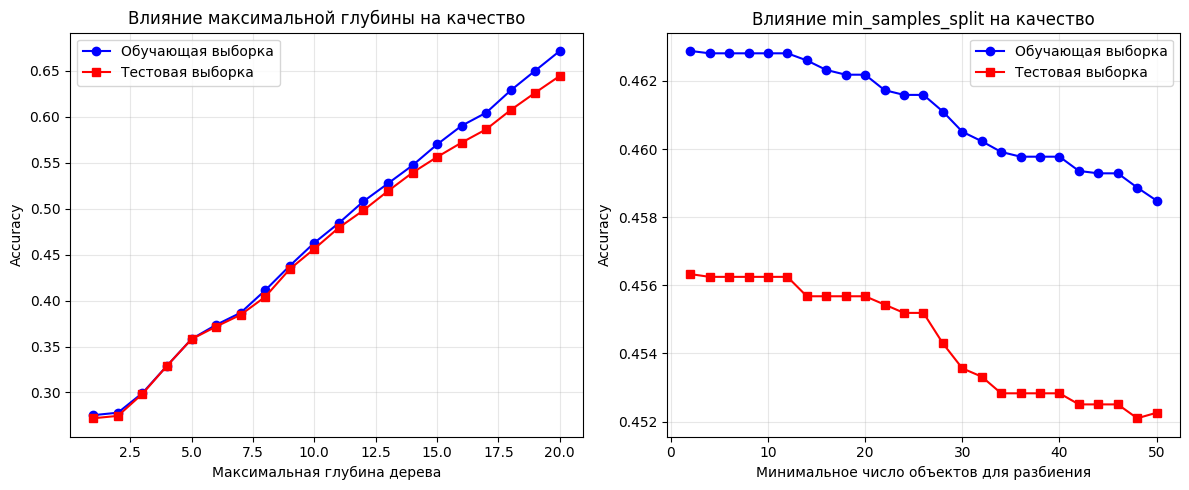

In [ ]:
# Исследование влияния максимальной глубины
depths = range(1, 21)
train_scores_depth = []
test_scores_depth = []

for depth in depths:
    dt = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        min_samples_split=2,
        random_state=42
    )
    dt.fit(X_train_final, y_train)
    
    train_scores_depth.append(accuracy_score(y_train, dt.predict(X_train_final)))
    test_scores_depth.append(accuracy_score(y_test, dt.predict(X_test_final)))

# Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(depths, train_scores_depth, 'b-', label='Обучающая выборка', marker='o')
plt.plot(depths, test_scores_depth, 'r-', label='Тестовая выборка', marker='s')
plt.xlabel('Максимальная глубина дерева')
plt.ylabel('Accuracy')
plt.title('Влияние максимальной глубины на качество')
plt.legend()
plt.grid(True, alpha=0.3)

# Исследование влияния минимального числа объектов для разбиения
min_samples = range(2, 51, 2)
train_scores_samples = []
test_scores_samples = []

for min_sample in min_samples:
    dt = DecisionTreeClassifier(
        criterion='gini',
        max_depth=10,  # фиксируем глубину для чистоты эксперимента
        min_samples_split=min_sample,
        random_state=42
    )
    dt.fit(X_train_final, y_train)
    
    train_scores_samples.append(accuracy_score(y_train, dt.predict(X_train_final)))
    test_scores_samples.append(accuracy_score(y_test, dt.predict(X_test_final)))

plt.subplot(1, 2, 2)
plt.plot(min_samples, train_scores_samples, 'b-', label='Обучающая выборка', marker='o')
plt.plot(min_samples, test_scores_samples, 'r-', label='Тестовая выборка', marker='s')
plt.xlabel('Минимальное число объектов для разбиения')
plt.ylabel('Accuracy')
plt.title('Влияние min_samples_split на качество')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
param_grid = {
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [5, 8, 10, 12, 15],
    'min_samples_leaf': [1, 3, 5]
}

dt_base = DecisionTreeClassifier(criterion='gini', random_state=42)

grid_dt = GridSearchCV(dt_base, param_grid, 
                           cv=3, scoring='accuracy', n_jobs=-1)

grid_dt.fit(X_train_final, y_train)

print("Лучшие параметры:", grid_dt.best_params_)
print("Лучшая точность на кросс-валидации:", grid_dt.best_score_)

dt_optimal = grid_dt.best_estimator_
y_pred_dt_optimal = dt_optimal.predict(X_test_final)

print("\n--- Итоговая модель дерева решений ---")
print(f"Accuracy на тесте: {accuracy_score(y_test, y_pred_dt_optimal):.4f}")
print(f"Глубина дерева: {dt_optimal.get_depth()}")
print(f"Количество листьев: {dt_optimal.get_n_leaves()}")
print(f"Количество признаков, использованных для разбиений: {dt_optimal.tree_.n_features}")

Лучшие параметры: {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 5}
Лучшая точность на кросс-валидации: 0.680644835724234

--- Итоговая модель дерева решений ---
Accuracy на тесте: 0.7184
Глубина дерева: 25
Количество листьев: 1045
Количество признаков, использованных для разбиений: 1017



Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.67      0.79       704
           2       0.83      0.22      0.34       115
          10       0.88      0.75      0.81      1942
          15       0.77      0.63      0.69       276
          17       0.86      0.64      0.73       652
          19       0.84      0.43      0.57       121
          20       0.92      0.69      0.79       245
          22       0.83      0.56      0.67       963
          23       0.94      0.73      0.82      1037
          24       0.50      0.94      0.65      2989
          25       0.89      0.67      0.77       746
          26       0.97      0.66      0.78      1244
          27       0.97      0.73      0.83       497
          28       0.97      0.34      0.51       720
          29       1.00      0.24      0.38        17
          43       1.00      0.35      0.52        17

    accuracy                           0.72     12285
  

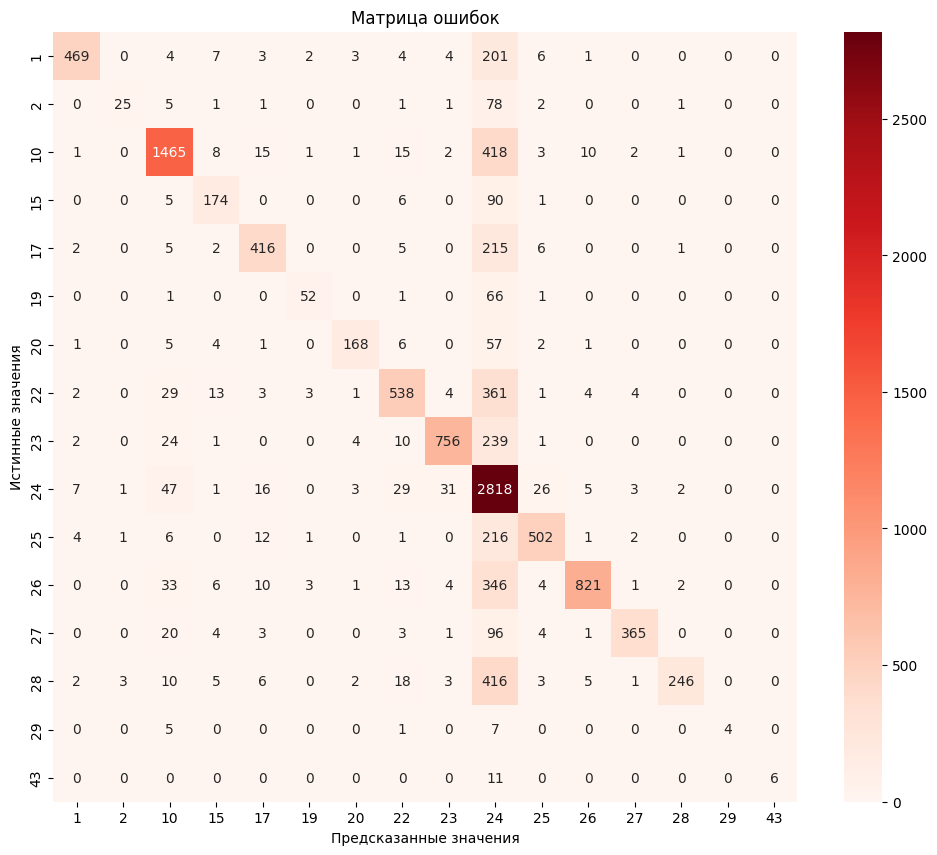

In [65]:
dt_accuracy, dt_precision, dt_recall, dt_f1 = scores(y_pred_dt_optimal)
report(y_pred_dt_optimal)

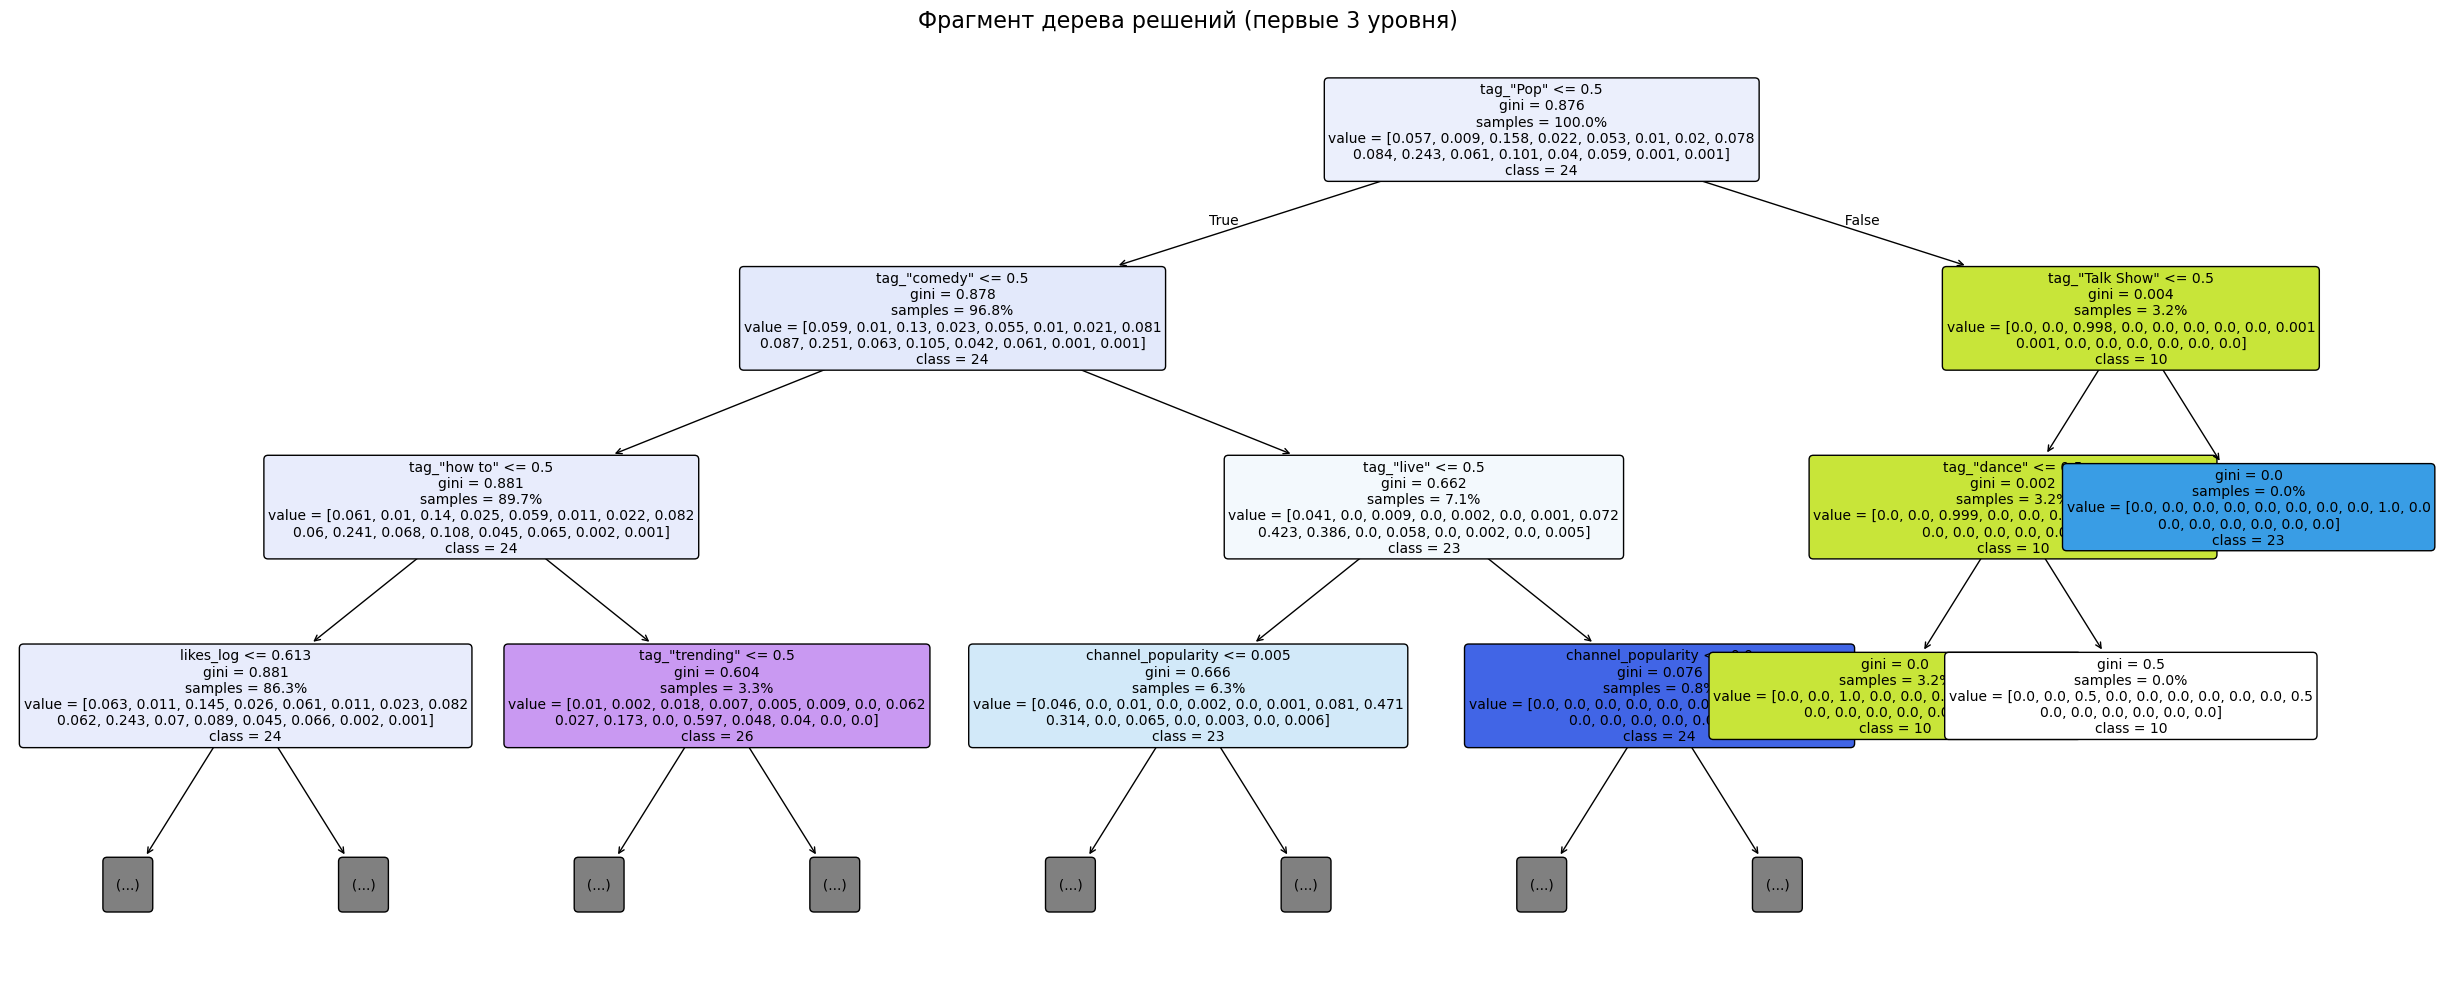

In [ ]:
plt.figure(figsize=(25, 10))
plot_tree(dt_optimal, 
          max_depth=3,
          feature_names=X_train_final.columns,
          class_names=[str(c) for c in dt_optimal.classes_],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True)
plt.title('Фрагмент дерева решений (первые 3 уровня)', fontsize=16)
plt.tight_layout()
plt.show()

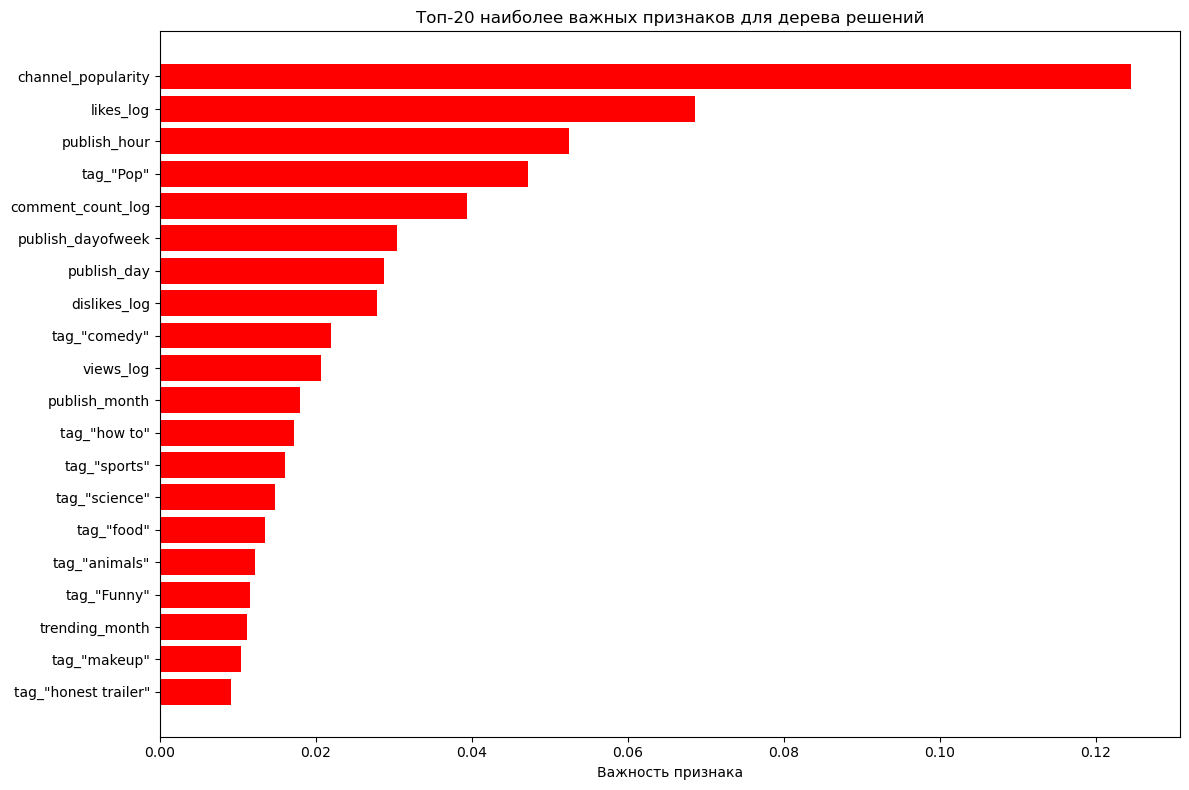

Топ-10 наиболее важных признаков:
  channel_popularity: 0.124566
  likes_log: 0.068584
  publish_hour: 0.052474
  tag_"Pop": 0.047139
  comment_count_log: 0.039425
  publish_dayofweek: 0.030429
  publish_day: 0.028694
  dislikes_log: 0.027799
  tag_"comedy": 0.021985
  views_log: 0.020671


In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': dt_optimal.feature_importances_
}).sort_values('importance', ascending=False)

top_20_features = feature_importance.head(20)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_20_features)), top_20_features['importance'].values, align='center', color=color)
plt.yticks(range(len(top_20_features)), top_20_features['feature'].values)
plt.xlabel('Важность признака')
plt.title('Топ-20 наиболее важных признаков для дерева решений')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Топ-10 наиболее важных признаков:")
for idx, row in top_20_features.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.6f}")

### 2.6. Сравнительный анализ

In [158]:
classification_results = pd.DataFrame([
    {"Method": "Наивный Байес (комбинированный)", "Accuracy": nb_accuracy, "Precision": nb_precision, "Recall": nb_recall, "F1-score": nb_f1},
    {"Method": "Логистическая регрессия", "Accuracy": logreg_accuracy, "Precision": logreg_precision, "Recall": logreg_recall, "F1-score": logreg_f1},
    {"Method": f"k-ближайших соседей (k={best_k})", "Accuracy": knn_accuracy, "Precision": knn_precision, "Recall": knn_recall, "F1-score": knn_f1},
    {"Method": f"Линейный SVM {grid_linearsvc.best_params_}", "Accuracy": linearsvc_accuracy, "Precision": linearsvc_precision, "Recall": linearsvc_recall, "F1-score": linearsvc_f1},
    {"Method": f"Дерево решений {grid_dt.best_params_}", "Accuracy": dt_accuracy, "Precision": dt_precision, "Recall": dt_recall, "F1-score": dt_f1}
])

classification_results

,Method,Accuracy,Precision,Recall,F1-score
0,Наивный Байес (комбинированный),0.640863,0.710585,0.495122,0.549990
1,Логистическая регрессия,0.285470,0.164067,0.090415,0.063610
2,k-ближайших соседей (k=1),0.818152,0.802249,0.796273,0.797589
3,Линейный SVM {'C': 100},0.718030,0.760272,0.609226,0.656074
4,"Дерево решений {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 5}",0.718356,0.882261,0.578099,0.665998


## 6 Применение ансамблевых моделей машинного обучения и регуляризации

### 6.1 Бэггинг (Bagging)

In [ ]:
estimators_grid = [10, 40, 70, 100]
bagging_preds = []
bagging_accuracies = []
bagging_precisions = []
bagging_recalls = []
bagging_f1s = []

for n_est in estimators_grid:
    bagging_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=None, random_state=42),
        n_estimators=n_est,
        random_state=42,
        n_jobs=-1
    )
    bagging_model.fit(X_train_final, y_train)
    
    bagging_pred = bagging_model.predict(X_test_final)
    bagging_preds.append(bagging_pred)
    
    accuracy, precision, recall, f1 = scores(bagging_pred)
    bagging_accuracies.append(accuracy)
    bagging_precisions.append(precision)
    bagging_recalls.append(recall)
    bagging_f1s.append(f1)
    print(f"Бэггинг ({n_est} деревьев): Accuracy = {accuracy:.4f}")

Бэггинг (10 деревьев): Accuracy = 0.9665
Бэггинг (40 деревьев): Accuracy = 0.9722
Бэггинг (70 деревьев): Accuracy = 0.9734
Бэггинг (100 деревьев): Accuracy = 0.9733


In [163]:
bagging_results = pd.concat(
    [pd.DataFrame([{
        'Method': 'Single (Optimal) Decision Tree',
        'M': "",
        'Accuracy': dt_accuracy,
        'Precision': dt_precision,
        'Recall': dt_recall,
        'F1-score': dt_f1
    }]), 
    pd.DataFrame({
        'Method': 'Bagging',
        'M': estimators_grid,
        'Accuracy': bagging_accuracies,
        'Precision': bagging_precisions,
        'Recall': bagging_recalls,
        'F1-score': bagging_f1s
    })],
    ignore_index=True)

bagging_results

,Method,M,Accuracy,Precision,Recall,F1-score
0,Single (Optimal) Decision Tree,,0.718356,0.882261,0.578099,0.665998
1,Bagging,10,0.966545,0.967627,0.961889,0.964651
2,Bagging,40,0.972243,0.977441,0.966687,0.971889
3,Bagging,70,0.973382,0.977831,0.968555,0.973057
4,Bagging,100,0.973301,0.977914,0.967253,0.972392


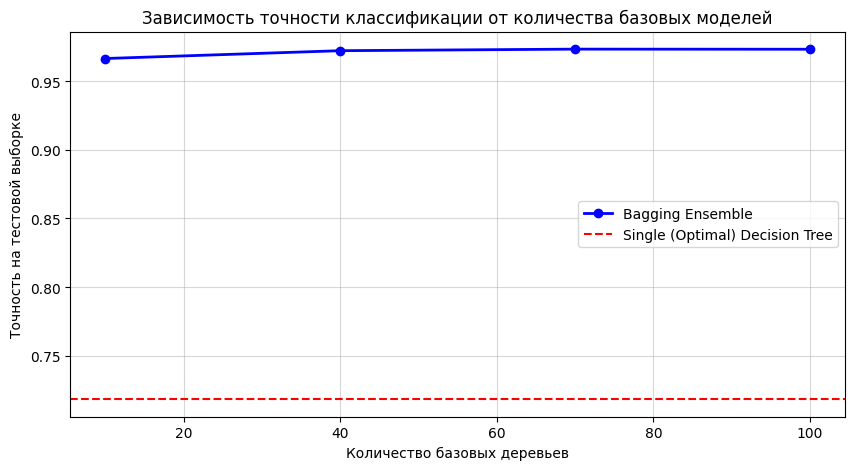

In [106]:
plt.figure(figsize=(10, 5))
plt.plot(estimators_grid, bagging_accuracies, marker='o', color='blue', linewidth=2, label='Bagging Ensemble')
plt.axhline(y=dt_accuracy, color='red', linestyle='--', linewidth=1.5, label=f'Single (Optimal) Decision Tree')
plt.title('Зависимость точности классификации от количества базовых моделей')
plt.xlabel('Количество базовых деревьев')
plt.ylabel('Точность на тестовой выборке')
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

### 6.2 Бустинг (Boosting)

In [97]:
def fix_json(X):
    X_fixed = X.copy()
    X_fixed.columns = [re.sub(r'[\[\]\,\:\s\"]', '_', str(col)) for col in X_fixed.columns]
    return X_fixed

X_train_lgb = fix_json(X_train_final)
X_test_lgb = fix_json(X_test_final)

In [112]:
iterations_range = [10, 40, 70, 100, 130, 160]
boosting_accuracies = []
boosting_precisions = []
boosting_recalls = []
boosting_f1s = []

train_accuracies = []
test_accuracies = []

for n_est in iterations_range:
    lgb_model = lgb.LGBMClassifier(
        n_estimators=n_est,
        max_depth=None,
        learning_rate=0.1,
        objective='multiclass',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgb_model.fit(X_train_lgb, y_train)
    
    train_pred = lgb_model.predict(X_train_lgb)
    test_pred = lgb_model.predict(X_test_lgb)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    accuracy, precision, recall, f1 = scores(test_pred)
    boosting_accuracies.append(accuracy)
    boosting_precisions.append(precision)
    boosting_recalls.append(recall)
    boosting_f1s.append(f1)
    
    print(f"Итераций: {n_est}\tTrain Accuracy: {train_acc:.4f}\tTest Accuracy: {test_acc:.4f}")

Итераций: 10	Train Accuracy: 0.8064	Test Accuracy: 0.7744
Итераций: 40	Train Accuracy: 0.9425	Test Accuracy: 0.9013
Итераций: 70	Train Accuracy: 0.9803	Test Accuracy: 0.9463
Итераций: 100	Train Accuracy: 0.9949	Test Accuracy: 0.9648
Итераций: 130	Train Accuracy: 0.9987	Test Accuracy: 0.9721
Итераций: 160	Train Accuracy: 0.9996	Test Accuracy: 0.9760


In [165]:
boosting_results = pd.concat(
    [bagging_results, 
    pd.DataFrame({
        'Method': 'Boosting',
        'M': iterations_range,
        'Accuracy': boosting_accuracies,
        'Precision': boosting_precisions,
        'Recall': boosting_recalls,
        'F1-score': boosting_f1s
    })],
    ignore_index=True)

boosting_results[boosting_results['Method'] != "Bagging"]

,Method,M,Accuracy,Precision,Recall,F1-score
0,Single (Optimal) Decision Tree,,0.718356,0.882261,0.578099,0.665998
5,Boosting,10,0.774359,0.814442,0.763891,0.773010
6,Boosting,40,0.901343,0.924302,0.903712,0.912438
7,Boosting,70,0.946276,0.962512,0.939125,0.950013
8,Boosting,100,0.964835,0.972209,0.953305,0.962089
9,Boosting,130,0.972080,0.976632,0.959965,0.967672
10,Boosting,160,0.975987,0.979723,0.964717,0.971657


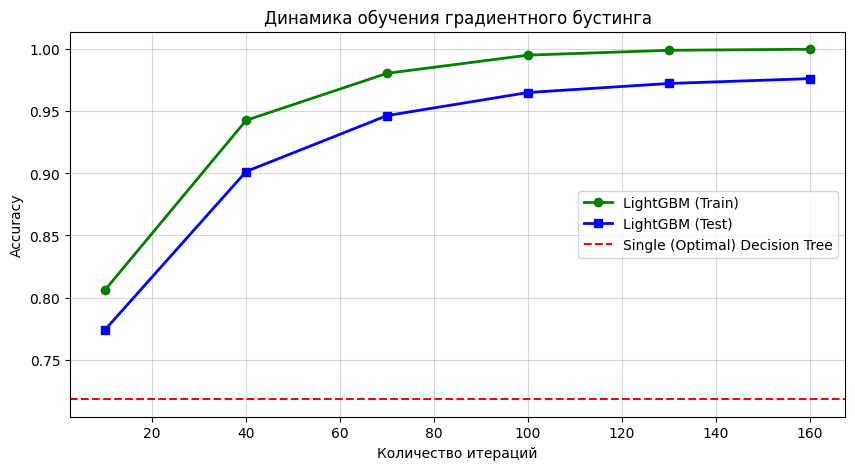

In [129]:
plt.figure(figsize=(10, 5))
plt.plot(iterations_range, train_accuracies, marker='o', color='green', linewidth=2, label='LightGBM (Train)')
plt.plot(iterations_range, test_accuracies, marker='s', color='blue', linewidth=2, label='LightGBM (Test)')
plt.axhline(y=dt_accuracy, color='red', linestyle='--', linewidth=1.5, label='Single (Optimal) Decision Tree')
plt.title('Динамика обучения градиентного бустинга')
plt.xlabel('Количество итераций')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

### 6.3 Стекинг (Stacking)


Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.90      0.90       704
           2       0.74      0.82      0.78       115
          10       0.92      0.93      0.93      1942
          15       0.87      0.86      0.87       276
          17       0.93      0.92      0.93       652
          19       0.83      0.83      0.83       121
          20       0.94      0.91      0.93       245
          22       0.90      0.85      0.87       963
          23       0.94      0.95      0.94      1037
          24       0.90      0.92      0.91      2989
          25       0.90      0.89      0.89       746
          26       0.93      0.93      0.93      1244
          27       0.94      0.91      0.92       497
          28       0.88      0.84      0.86       720
          29       0.93      0.76      0.84        17
          43       1.00      1.00      1.00        17

    accuracy                           0.91     12285
  

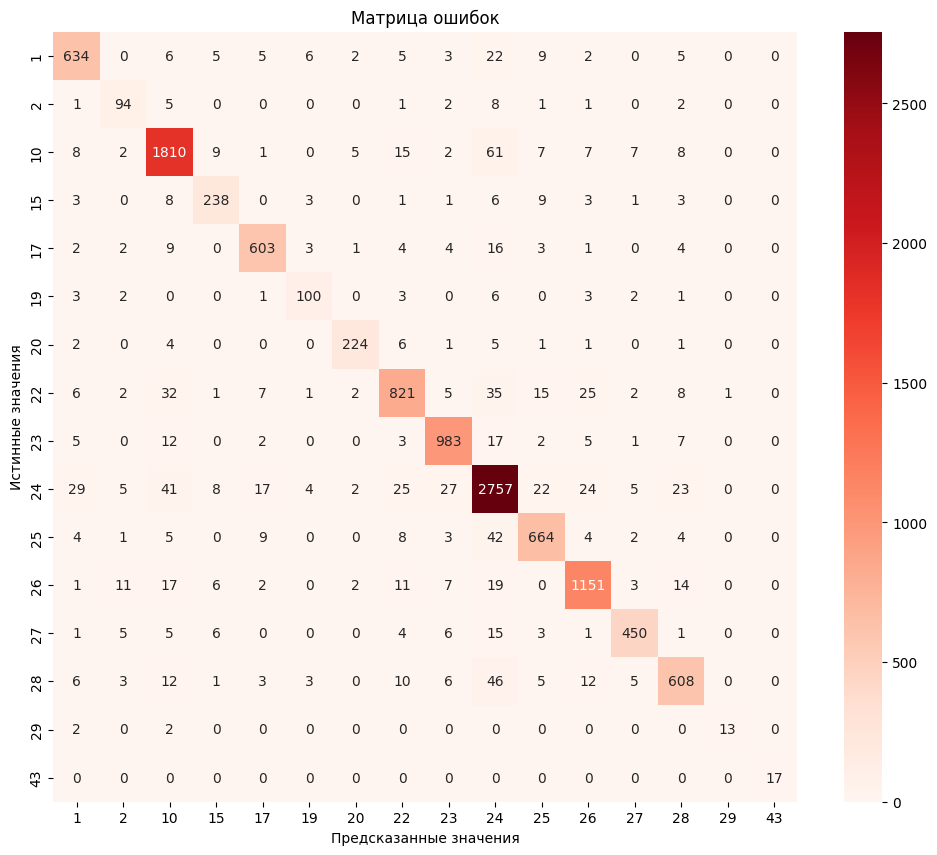

In [150]:
base_models = [
    ('knn', knn_optimal),
    ('svm', linearsvc_optimal),
    ('tree', dt_optimal)
]

meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1,
    passthrough=False  # Мета-модель обучается только на мета-признаках
)

stacking_model.fit(X_train_final, y_train)

stacking_pred = stacking_model.predict(X_test_final)
stacking_accuracy, stacking_precision, stacking_recall, stacking_f1 = scores(stacking_pred)
report(stacking_pred)

In [166]:
stacking_result = pd.concat(
    [classification_results.drop([0,1]), pd.DataFrame([{
        'Method': 'Stacking',
        'Accuracy': stacking_accuracy,
        'Precision': stacking_precision,
        'Recall': stacking_recall,
        'F1-score': stacking_f1
    }])],
    ignore_index=True
)

stacking_result

,Method,Accuracy,Precision,Recall,F1-score
0,k-ближайших соседей (k=1),0.818152,0.802249,0.796273,0.797589
1,Линейный SVM {'C': 100},0.718030,0.760272,0.609226,0.656074
2,"Дерево решений {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 5}",0.718356,0.882261,0.578099,0.665998
3,Stacking,0.908995,0.902383,0.889415,0.895177
